# IPL Data Analysis - 200 Practice Questions

**Data Science Instructor: Ananda Rimal**

This workbook contains:
- **150 Pandas questions**
- **50 Matplotlib + Seaborn visualization questions**
- **Total: 200 questions**

Use the same two IPL tables throughout the notebook: `matches.csv` and `deliveries.csv`.


## Dataset Download

Use the standard IPL dataset containing the two files **`matches.csv`** and **`deliveries.csv`**.

- **Kaggle dataset:** https://www.kaggle.com/datasets/nowke9/ipldata
- **GitHub fallback repository containing both IPL CSV files:** https://github.com/Martin-data-ds/IPL_match_prediction

Download the two CSV files and keep them in the same folder as this notebook (or update the file paths in the setup cell).

### Expected relationship
- `matches.id` = match identifier in the match table
- `deliveries.match_id` = match identifier in the ball-by-ball table

For Pandas merge questions, you can join with `left_on='id'` and `right_on='match_id'`.


## Student Instructions

1. Write the solution directly below each question in the provided code cell.
2. Run every cell and keep the output visible.
3. Use **Pandas only** for Questions 1-150.
4. Use **Matplotlib and Seaborn** for Questions 151-200.
5. Use clear titles, axis labels and legends where appropriate for visualization questions.
6. Do not delete the question text.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')

# Load the two IPL datasets (CSV files are kept in the project's data/ folder)
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

# This version of the dataset stores the season as text such as 'IPL-2017'.
# Create a numeric `season` column (e.g. 2017) that the questions use.
matches['season'] = matches['Season'].str[-4:].astype(int)

print('matches shape:', matches.shape)
print('deliveries shape:', deliveries.shape)

matches shape: (756, 19)
deliveries shape: (179078, 21)


# Section A - Loading, Series, DataFrame and Basic Inspection

### Question 1
Load `matches.csv` into a DataFrame named `matches` and display the first 5 rows.

In [2]:
matches = pd.read_csv('../data/matches.csv')
matches['season'] = matches['Season'].str[-4:].astype(int)  # numeric season from 'IPL-2017'
matches.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,2017
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2017
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,2017
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,2017
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,2017


### Question 2
Load `deliveries.csv` into a DataFrame named `deliveries` and display the first 5 rows.

In [3]:
deliveries = pd.read_csv('../data/deliveries.csv')
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN


### Question 3
Display the first 10 rows of the `matches` DataFrame.

In [4]:
matches.head(10)

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,2017
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2017
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,2017
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,2017
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,2017
5,6,IPL-2017,Hyderabad,09-04-2017,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",A Deshmukh,NJ Llong,NaN,2017
6,7,IPL-2017,Mumbai,09-04-2017,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,2017
7,8,IPL-2017,Indore,10-04-2017,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,bat,normal,0,Kings XI Punjab,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,2017
8,9,IPL-2017,Pune,11-04-2017,Delhi Daredevils,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Delhi Daredevils,97,0,SV Samson,Maharashtra Cricket Association Stadium,AY Dandekar,S Ravi,NaN,2017
9,10,IPL-2017,Mumbai,12-04-2017,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,2017


### Question 4
Display the last 10 rows of the `matches` DataFrame.

In [5]:
matches.tail(10)

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
746,11342,IPL-2019,Mumbai,02-05-2019,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,bat,tie,0,Mumbai Indians,0,0,JJ Bumrah,Wankhede Stadium,S Ravi,O Nandan,Nanda Kishore,2019
747,11343,IPL-2019,Mohali,03-05-2019,Kings XI Punjab,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,7,S Gill,IS Bindra Stadium,Bruce Oxenford,C Shamshuddin,KN Ananthapadmanabhan,2019
748,11344,IPL-2019,Delhi,04-05-2019,Rajasthan Royals,Delhi Capitals,Rajasthan Royals,bat,normal,0,Delhi Capitals,0,5,A Mishra,Feroz Shah Kotla Ground,Ian Gould,Anil Dandekar,Nitin Menon,2019
749,11345,IPL-2019,Bengaluru,04-05-2019,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,S Hetmyer,M. Chinnaswamy Stadium,Nigel Llong,Anil Chaudhary,Ulhas Gandhe,2019
750,11346,IPL-2019,Mohali,05-05-2019,Chennai Super Kings,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,KL Rahul,IS Bindra Stadium,KN Ananthapadmanabhan,C Shamshuddin,Bruce Oxenford,2019
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,2019
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould,2019
753,11413,IPL-2019,Visakhapatnam,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN,2019
754,11414,IPL-2019,Visakhapatnam,10-05-2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin,2019
755,11415,IPL-2019,Hyderabad,12-05-2019,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Mumbai Indians,1,0,JJ Bumrah,Rajiv Gandhi Intl. Cricket Stadium,Nitin Menon,Ian Gould,Nigel Llong,2019


### Question 5
Display the first 10 rows of the `deliveries` DataFrame.

In [6]:
deliveries.head(10)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN
5,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,6,S Dhawan,DA Warner,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
6,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,7,S Dhawan,DA Warner,TS Mills,0,0,0,1,0,0,0,1,1,NaN,NaN,NaN
7,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,1,S Dhawan,DA Warner,A Choudhary,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
8,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,2,DA Warner,S Dhawan,A Choudhary,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
9,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,3,DA Warner,S Dhawan,A Choudhary,0,0,0,0,1,0,0,1,1,NaN,NaN,NaN


### Question 6
Display the last 10 rows of the `deliveries` DataFrame.

In [7]:
deliveries.tail(10)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
179068,11415,2,Chennai Super Kings,Mumbai Indians,19,3,RA Jadeja,SR Watson,JJ Bumrah,0,0,0,0,0,0,2,0,2,NaN,NaN,NaN
179069,11415,2,Chennai Super Kings,Mumbai Indians,19,4,RA Jadeja,SR Watson,JJ Bumrah,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
179070,11415,2,Chennai Super Kings,Mumbai Indians,19,5,RA Jadeja,SR Watson,JJ Bumrah,0,0,0,0,0,0,2,0,2,NaN,NaN,NaN
179071,11415,2,Chennai Super Kings,Mumbai Indians,19,6,RA Jadeja,SR Watson,JJ Bumrah,0,0,4,0,0,0,4,4,8,NaN,NaN,NaN
179072,11415,2,Chennai Super Kings,Mumbai Indians,20,1,SR Watson,RA Jadeja,SL Malinga,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
179073,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
179074,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,0,0,0,0,0,2,0,2,NaN,NaN,NaN
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,0,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
179076,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,0,0,0,0,0,2,0,2,NaN,NaN,NaN
179077,11415,2,Chennai Super Kings,Mumbai Indians,20,6,SN Thakur,RA Jadeja,SL Malinga,0,0,0,0,0,0,0,0,0,SN Thakur,lbw,NaN


### Question 7
Find the number of rows and columns in `matches` using `shape`.

In [8]:
print('Rows:', matches.shape[0], '| Columns:', matches.shape[1])
matches.shape

Rows: 756 | Columns: 19


(756, 19)

### Question 8
Find the number of rows and columns in `deliveries` using `shape`.

In [9]:
print('Rows:', deliveries.shape[0], '| Columns:', deliveries.shape[1])
deliveries.shape

Rows: 179078 | Columns: 21


(179078, 21)

### Question 9
Use `info()` to inspect column names, data types and missing values in `matches`.

In [10]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

### Question 10
Use `info()` to inspect column names, data types and missing values in `deliveries`.

In [11]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          179078 non-null  int64 
 1   inning            179078 non-null  int64 
 2   batting_team      179078 non-null  object
 3   bowling_team      179078 non-null  object
 4   over              179078 non-null  int64 
 5   ball              179078 non-null  int64 
 6   batsman           179078 non-null  object
 7   non_striker       179078 non-null  object
 8   bowler            179078 non-null  object
 9   is_super_over     179078 non-null  int64 
 10  wide_runs         179078 non-null  int64 
 11  bye_runs          179078 non-null  int64 
 12  legbye_runs       179078 non-null  int64 
 13  noball_runs       179078 non-null  int64 
 14  penalty_runs      179078 non-null  int64 
 15  batsman_runs      179078 non-null  int64 
 16  extra_runs        179078 non-null  int

### Question 11
Use `describe()` on `matches` and study the numerical summary.

In [12]:
matches.describe()

,id,dl_applied,win_by_runs,win_by_wickets,season
count,756.000000,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,0.025132,13.283069,3.350529,2013.444444
std,3464.478148,0.156630,23.471144,3.387963,3.366895
min,1.000000,0.000000,0.000000,0.000000,2008.000000
25%,189.750000,0.000000,0.000000,0.000000,2011.000000
50%,378.500000,0.000000,0.000000,4.000000,2013.000000
75%,567.250000,0.000000,19.000000,6.000000,2016.000000
max,11415.000000,1.000000,146.000000,10.000000,2019.000000


### Question 12
Use `describe()` on `deliveries` and study the numerical summary.

In [13]:
deliveries.describe()

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs
count,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000,179078.000000
mean,1802.252957,1.482952,10.162488,3.615587,0.000452,0.036721,0.004936,0.021136,0.004183,0.000056,1.246864,0.067032,1.313897
std,3472.322805,0.502074,5.677684,1.806966,0.021263,0.251161,0.116480,0.194908,0.070492,0.016709,1.608270,0.342553,1.605422
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,190.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,379.000000,1.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,567.000000,2.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,11415.000000,5.000000,20.000000,9.000000,1.000000,5.000000,4.000000,5.000000,5.000000,5.000000,7.000000,7.000000,10.000000


### Question 13
Display 8 random rows from `matches` using `sample()`.

In [14]:
matches.sample(8, random_state=42)

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
408,409,IPL-2013,Chandigarh,21-04-2013,Pune Warriors,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,7,DA Miller,"Punjab Cricket Association Stadium, Mohali",M Erasmus,K Srinath,NaN,2013
97,98,IPL-2008,Delhi,15-05-2008,Delhi Daredevils,Deccan Chargers,Deccan Chargers,field,normal,0,Delhi Daredevils,12,0,A Mishra,Feroz Shah Kotla,BG Jerling,GA Pratapkumar,NaN,2008
424,425,IPL-2013,Chennai,02-05-2013,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,15,0,SK Raina,"MA Chidambaram Stadium, Chepauk",M Erasmus,VA Kulkarni,NaN,2013
584,585,IPL-2016,Mumbai,16-04-2016,Mumbai Indians,Gujarat Lions,Gujarat Lions,field,normal,0,Gujarat Lions,0,3,AJ Finch,Wankhede Stadium,HDPK Dharmasena,VK Sharma,NaN,2016
603,604,IPL-2016,Rajkot,01-05-2016,Kings XI Punjab,Gujarat Lions,Gujarat Lions,field,normal,0,Kings XI Punjab,23,0,AR Patel,Saurashtra Cricket Association Stadium,BNJ Oxenford,VK Sharma,NaN,2016
78,79,IPL-2008,Chennai,02-05-2008,Chennai Super Kings,Delhi Daredevils,Chennai Super Kings,bat,normal,0,Delhi Daredevils,0,8,V Sehwag,"MA Chidambaram Stadium, Chepauk",BF Bowden,K Hariharan,NaN,2008
54,55,IPL-2017,Delhi,14-05-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,10,0,HV Patel,Feroz Shah Kotla,CK Nandan,C Shamshuddin,NaN,2017
109,110,IPL-2008,Chennai,24-05-2008,Rajasthan Royals,Chennai Super Kings,Rajasthan Royals,bat,normal,0,Rajasthan Royals,10,0,JA Morkel,"MA Chidambaram Stadium, Chepauk",DJ Harper,SL Shastri,NaN,2008


### Question 14
Display 8 random rows from `deliveries` using `sample()`.

In [15]:
deliveries.sample(8, random_state=42)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
10557,45,2,Kolkata Knight Riders,Royal Challengers Bangalore,5,5,SP Narine,CA Lynn,S Aravind,0,1,0,0,0,0,0,1,1,NaN,NaN,NaN
2086,9,2,Rising Pune Supergiant,Delhi Daredevils,12,3,MS Dhoni,R Bhatia,A Mishra,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
142206,601,2,Gujarat Lions,Rising Pune Supergiants,15,5,KD Karthik,SK Raina,M Ashwin,0,0,0,0,0,0,2,0,2,NaN,NaN,NaN
45359,193,1,Rajasthan Royals,Kings XI Punjab,7,2,MJ Lumb,FY Fazal,J Theron,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
10303,44,1,Mumbai Indians,Delhi Daredevils,18,2,KA Pollard,HH Pandya,CJ Anderson,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
98946,418,1,Chennai Super Kings,Kolkata Knight Riders,4,6,WP Saha,MEK Hussey,Mohammed Shami,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
95915,405,1,Kings XI Punjab,Sunrisers Hyderabad,20,1,AD Mascarenhas,P Kumar,NLTC Perera,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
141914,600,2,Mumbai Indians,Kolkata Knight Riders,7,1,RG Sharma,AT Rayudu,Shakib Al Hasan,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN


### Question 15
Select only the `winner` column from `matches` and verify that the result is a Pandas Series.

In [16]:
winner = matches['winner']
print(type(winner))
print('Is a Series:', isinstance(winner, pd.Series))
winner.head()

<class 'pandas.core.series.Series'>
Is a Series: True


0            Sunrisers Hyderabad
1         Rising Pune Supergiant
2          Kolkata Knight Riders
3                Kings XI Punjab
4    Royal Challengers Bangalore
Name: winner, dtype: object

### Question 16
Select the columns `season`, `team1`, `team2`, and `winner` from `matches` as a DataFrame.

In [17]:
matches[['season', 'team1', 'team2', 'winner']]

,season,team1,team2,winner
0,2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad
1,2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant
2,2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders
3,2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab
4,2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore
...,...,...,...,...
751,2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians
752,2019,Chennai Super Kings,Mumbai Indians,Mumbai Indians
753,2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals
754,2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings


### Question 17
Select only the `batsman` column from `deliveries` as a Series.

In [18]:
batsman = deliveries['batsman']
print(type(batsman))
batsman.head()

<class 'pandas.core.series.Series'>


0    DA Warner
1    DA Warner
2    DA Warner
3    DA Warner
4    DA Warner
Name: batsman, dtype: object

### Question 18
Select the columns `match_id`, `batting_team`, `batsman`, `bowler`, and `total_runs` from `deliveries`.

In [19]:
deliveries[['match_id', 'batting_team', 'batsman', 'bowler', 'total_runs']]

,match_id,batting_team,batsman,bowler,total_runs
0,1,Sunrisers Hyderabad,DA Warner,TS Mills,0
1,1,Sunrisers Hyderabad,DA Warner,TS Mills,0
2,1,Sunrisers Hyderabad,DA Warner,TS Mills,4
3,1,Sunrisers Hyderabad,DA Warner,TS Mills,0
4,1,Sunrisers Hyderabad,DA Warner,TS Mills,2
...,...,...,...,...,...
179073,11415,Chennai Super Kings,RA Jadeja,SL Malinga,1
179074,11415,Chennai Super Kings,SR Watson,SL Malinga,2
179075,11415,Chennai Super Kings,SR Watson,SL Malinga,1
179076,11415,Chennai Super Kings,SN Thakur,SL Malinga,2


### Question 19
Create a new DataFrame containing only `season`, `city`, `venue`, and `winner` from `matches`.

In [20]:
match_info = matches[['season', 'city', 'venue', 'winner']].copy()
match_info.head()

,season,city,venue,winner
0,2017,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad
1,2017,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant
2,2017,Rajkot,Saurashtra Cricket Association Stadium,Kolkata Knight Riders
3,2017,Indore,Holkar Cricket Stadium,Kings XI Punjab
4,2017,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore


### Question 20
Create a new DataFrame containing only `match_id`, `over`, `ball`, `batsman_runs`, `extra_runs`, and `total_runs` from `deliveries`.

In [21]:
ball_runs = deliveries[['match_id', 'over', 'ball', 'batsman_runs', 'extra_runs', 'total_runs']].copy()
ball_runs.head()

,match_id,over,ball,batsman_runs,extra_runs,total_runs
0,1,1,1,0,0,0
1,1,1,2,0,0,0
2,1,1,3,4,0,4
3,1,1,4,0,0,0
4,1,1,5,0,2,2


# Section B - Selection, loc, iloc and Conditional Filtering

### Question 21
Use `iloc` to display the first row of `matches`.

In [22]:
matches.iloc[0]

id                                                         1
Season                                              IPL-2017
city                                               Hyderabad
date                                              05-04-2017
team1                                    Sunrisers Hyderabad
team2                            Royal Challengers Bangalore
toss_winner                      Royal Challengers Bangalore
toss_decision                                          field
result                                                normal
dl_applied                                                 0
winner                                   Sunrisers Hyderabad
win_by_runs                                               35
win_by_wickets                                             0
player_of_match                                 Yuvraj Singh
venue              Rajiv Gandhi International Stadium, Uppal
umpire1                                          AY Dandekar
umpire2                 

### Question 22
Use `iloc` to display the first 5 rows and first 5 columns of `matches`.

In [23]:
matches.iloc[:5, :5]

,id,Season,city,date,team1
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore


### Question 23
Use `iloc` to display rows 10 to 19 of `deliveries`.

In [24]:
deliveries.iloc[10:20]

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
10,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,4,DA Warner,S Dhawan,A Choudhary,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
11,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,5,DA Warner,S Dhawan,A Choudhary,0,0,0,0,0,0,0,0,0,DA Warner,caught,Mandeep Singh
12,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,6,MC Henriques,S Dhawan,A Choudhary,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
13,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,7,MC Henriques,S Dhawan,A Choudhary,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
14,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,3,1,S Dhawan,MC Henriques,TS Mills,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
15,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,3,2,MC Henriques,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
16,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,3,3,MC Henriques,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
17,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,3,4,MC Henriques,S Dhawan,TS Mills,0,0,0,0,0,0,3,0,3,NaN,NaN,NaN
18,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,3,5,S Dhawan,MC Henriques,TS Mills,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
19,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,3,6,MC Henriques,S Dhawan,TS Mills,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN


### Question 24
Use `iloc` to display the first 10 rows and the columns from position 0 to 5 in `deliveries`.

In [25]:
deliveries.iloc[:10, 0:6]

,match_id,inning,batting_team,bowling_team,over,ball
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5
5,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,6
6,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,7
7,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,1
8,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,2
9,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,3


### Question 25
Use `loc` to display the first 20 rows with columns `batsman`, `bowler`, and `total_runs` from `deliveries`.

In [26]:
deliveries.loc[:19, ['batsman', 'bowler', 'total_runs']]

,batsman,bowler,total_runs
0,DA Warner,TS Mills,0
1,DA Warner,TS Mills,0
2,DA Warner,TS Mills,4
3,DA Warner,TS Mills,0
4,DA Warner,TS Mills,2
5,S Dhawan,TS Mills,0
6,S Dhawan,TS Mills,1
7,S Dhawan,A Choudhary,1
8,DA Warner,A Choudhary,4
9,DA Warner,A Choudhary,1


### Question 26
Display all matches played in the 2017 season.

In [27]:
matches[matches['season'] == 2017]

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,2017
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2017
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,2017
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,2017
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,2017
5,6,IPL-2017,Hyderabad,09-04-2017,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",A Deshmukh,NJ Llong,NaN,2017
6,7,IPL-2017,Mumbai,09-04-2017,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,2017
7,8,IPL-2017,Indore,10-04-2017,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,bat,normal,0,Kings XI Punjab,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,2017
8,9,IPL-2017,Pune,11-04-2017,Delhi Daredevils,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Delhi Daredevils,97,0,SV Samson,Maharashtra Cricket Association Stadium,AY Dandekar,S Ravi,NaN,2017
9,10,IPL-2017,Mumbai,12-04-2017,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,2017


### Question 27
Display all matches where the toss decision was `field`.

In [28]:
matches[matches['toss_decision'] == 'field']

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,2017
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2017
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,2017
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,2017
5,6,IPL-2017,Hyderabad,09-04-2017,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",A Deshmukh,NJ Llong,NaN,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749,11345,IPL-2019,Bengaluru,04-05-2019,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,S Hetmyer,M. Chinnaswamy Stadium,Nigel Llong,Anil Chaudhary,Ulhas Gandhe,2019
750,11346,IPL-2019,Mohali,05-05-2019,Chennai Super Kings,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,KL Rahul,IS Bindra Stadium,KN Ananthapadmanabhan,C Shamshuddin,Bruce Oxenford,2019
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,2019
753,11413,IPL-2019,Visakhapatnam,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN,2019


### Question 28
Display all matches won by `Mumbai Indians`.

In [29]:
matches[matches['winner'] == 'Mumbai Indians']

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
6,7,IPL-2017,Mumbai,09-04-2017,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,2017
9,10,IPL-2017,Mumbai,12-04-2017,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,2017
11,12,IPL-2017,Bangalore,14-04-2017,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,KA Pollard,M Chinnaswamy Stadium,KN Ananthapadmanabhan,AK Chaudhary,NaN,2017
15,16,IPL-2017,Mumbai,16-04-2017,Gujarat Lions,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,6,N Rana,Wankhede Stadium,A Nand Kishore,S Ravi,NaN,2017
21,22,IPL-2017,Indore,20-04-2017,Kings XI Punjab,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,8,JC Buttler,Holkar Cricket Stadium,M Erasmus,C Shamshuddin,NaN,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,11335,IPL-2019,Chennai,26-04-2019,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,field,normal,0,Mumbai Indians,46,0,RG Sharma,M. A. Chidambaram Stadium,Nigel Llong,Anil Chaudhary,Vineet Kulkarni,2019
746,11342,IPL-2019,Mumbai,02-05-2019,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,bat,tie,0,Mumbai Indians,0,0,JJ Bumrah,Wankhede Stadium,S Ravi,O Nandan,Nanda Kishore,2019
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,2019
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould,2019


### Question 29
Display the `season`, `team1`, `team2`, and `winner` for matches won by `Chennai Super Kings`.

In [30]:
matches.loc[matches['winner'] == 'Chennai Super Kings', ['season', 'team1', 'team2', 'winner']]

,season,team1,team2,winner
60,2008,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings
66,2008,Chennai Super Kings,Mumbai Indians,Chennai Super Kings
70,2008,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings
73,2008,Chennai Super Kings,Royal Challengers Bangalore,Chennai Super Kings
86,2008,Delhi Daredevils,Chennai Super Kings,Chennai Super Kings
...,...,...,...,...
720,2019,Rajasthan Royals,Chennai Super Kings,Chennai Super Kings
724,2019,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings
736,2019,Sunrisers Hyderabad,Chennai Super Kings,Chennai Super Kings
745,2019,Chennai Super Kings,Delhi Capitals,Chennai Super Kings


### Question 30
Display all matches played in the city `Mumbai`.

In [31]:
matches[matches['city'] == 'Mumbai']

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
6,7,IPL-2017,Mumbai,09-04-2017,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,2017
9,10,IPL-2017,Mumbai,12-04-2017,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,2017
15,16,IPL-2017,Mumbai,16-04-2017,Gujarat Lions,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,6,N Rana,Wankhede Stadium,A Nand Kishore,S Ravi,NaN,2017
23,24,IPL-2017,Mumbai,22-04-2017,Mumbai Indians,Delhi Daredevils,Delhi Daredevils,field,normal,0,Mumbai Indians,14,0,MJ McClenaghan,Wankhede Stadium,A Nand Kishore,S Ravi,NaN,2017
27,28,IPL-2017,Mumbai,24-04-2017,Rising Pune Supergiant,Mumbai Indians,Mumbai Indians,field,normal,0,Rising Pune Supergiant,3,0,BA Stokes,Wankhede Stadium,A Nand Kishore,S Ravi,NaN,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
719,11315,IPL-2019,Mumbai,10-04-2019,Kings XI Punjab,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,3,KA Pollard,Wankhede Stadium,Yeshwant Barde,S Ravi,O Nandan,2019
722,11318,IPL-2019,Mumbai,13-04-2019,Mumbai Indians,Rajasthan Royals,Rajasthan Royals,field,normal,0,Rajasthan Royals,0,4,JC Buttler,Wankhede Stadium,Nitin Menon,Nanda Kishore,Marais Erasmus,2019
726,11322,IPL-2019,Mumbai,15-04-2019,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,5,SL Malinga,Wankhede Stadium,Marais Erasmus,Nitin Menon,Nanda Kishore,2019
746,11342,IPL-2019,Mumbai,02-05-2019,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,bat,tie,0,Mumbai Indians,0,0,JJ Bumrah,Wankhede Stadium,S Ravi,O Nandan,Nanda Kishore,2019


### Question 31
Display all matches where `win_by_runs` was greater than 50.

In [32]:
matches[matches['win_by_runs'] > 50]

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
8,9,IPL-2017,Pune,11-04-2017,Delhi Daredevils,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Delhi Daredevils,97,0,SV Samson,Maharashtra Cricket Association Stadium,AY Dandekar,S Ravi,NaN,2017
14,15,IPL-2017,Delhi,15-04-2017,Delhi Daredevils,Kings XI Punjab,Delhi Daredevils,bat,normal,0,Delhi Daredevils,51,0,CJ Anderson,Feroz Shah Kotla,YC Barde,Nitin Menon,NaN,2017
26,27,IPL-2017,Kolkata,23-04-2017,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,82,0,NM Coulter-Nile,Eden Gardens,CB Gaffaney,CK Nandan,NaN,2017
32,33,IPL-2017,Pune,29-04-2017,Rising Pune Supergiant,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Rising Pune Supergiant,61,0,LH Ferguson,Maharashtra Cricket Association Stadium,KN Ananthapadmanabhan,M Erasmus,NaN,2017
43,44,IPL-2017,Delhi,06-05-2017,Mumbai Indians,Delhi Daredevils,Delhi Daredevils,field,normal,0,Mumbai Indians,146,0,LMP Simmons,Feroz Shah Kotla,Nitin Menon,CK Nandan,NaN,2017
59,60,IPL-2008,Bangalore,18-04-2008,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN,2008
68,69,IPL-2008,Chandigarh,25-04-2008,Kings XI Punjab,Mumbai Indians,Mumbai Indians,field,normal,0,Kings XI Punjab,66,0,KC Sangakkara,"Punjab Cricket Association Stadium, Mohali",Aleem Dar,AM Saheba,NaN,2008
100,101,IPL-2008,Jaipur,17-05-2008,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Rajasthan Royals,65,0,GC Smith,Sawai Mansingh Stadium,BF Bowden,SL Shastri,NaN,2008
114,115,IPL-2008,Mumbai,30-05-2008,Rajasthan Royals,Delhi Daredevils,Delhi Daredevils,field,normal,0,Rajasthan Royals,105,0,SR Watson,Wankhede Stadium,BF Bowden,RE Koertzen,NaN,2008
118,119,IPL-2009,Cape Town,18-04-2009,Royal Challengers Bangalore,Rajasthan Royals,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,75,0,R Dravid,Newlands,BR Doctrove,RB Tiffin,NaN,2009


### Question 32
Display all matches where `win_by_wickets` was 10.

In [33]:
matches[matches['win_by_wickets'] == 10]

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,2017
34,35,IPL-2017,Chandigarh,30-04-2017,Delhi Daredevils,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,10,Sandeep Sharma,"Punjab Cricket Association IS Bindra Stadium, ...",YC Barde,CK Nandan,NaN,2017
71,72,IPL-2008,Mumbai,27-04-2008,Mumbai Indians,Deccan Chargers,Deccan Chargers,field,normal,0,Deccan Chargers,0,10,AC Gilchrist,Dr DY Patil Sports Academy,Asad Rauf,SL Shastri,NaN,2008
119,120,IPL-2009,Cape Town,19-04-2009,Kings XI Punjab,Delhi Daredevils,Delhi Daredevils,field,normal,1,Delhi Daredevils,0,10,DL Vettori,Newlands,MR Benson,SD Ranade,NaN,2009
183,184,IPL-2010,Bangalore,18-03-2010,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,10,JH Kallis,M Chinnaswamy Stadium,K Hariharan,DJ Harper,NaN,2010
298,299,IPL-2011,Mumbai,20-05-2011,Mumbai Indians,Rajasthan Royals,Mumbai Indians,bat,normal,0,Rajasthan Royals,0,10,SR Watson,Wankhede Stadium,RE Koertzen,PR Reiffel,NaN,2011
376,377,IPL-2012,Jaipur,20-05-2012,Rajasthan Royals,Mumbai Indians,Rajasthan Royals,bat,normal,0,Mumbai Indians,0,10,DR Smith,Sawai Mansingh Stadium,HDPK Dharmasena,C Shamshuddin,NaN,2012
390,391,IPL-2013,Chandigarh,10-04-2013,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,10,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Aleem Dar,C Shamshuddin,NaN,2013
542,543,IPL-2015,Delhi,26-04-2015,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,10,VR Aaron,Feroz Shah Kotla,M Erasmus,S Ravi,NaN,2015
590,591,IPL-2016,Rajkot,21-04-2016,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,10,B Kumar,Saurashtra Cricket Association Stadium,K Bharatan,HDPK Dharmasena,NaN,2016


### Question 33
Display all matches where the toss winner and match winner were the same team.

In [34]:
matches[matches['toss_winner'] == matches['winner']]

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2017
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,2017
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,2017
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,2017
5,6,IPL-2017,Hyderabad,09-04-2017,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,Rashid Khan,"Rajiv Gandhi International Stadium, Uppal",A Deshmukh,NJ Llong,NaN,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,11346,IPL-2019,Mohali,05-05-2019,Chennai Super Kings,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,KL Rahul,IS Bindra Stadium,KN Ananthapadmanabhan,C Shamshuddin,Bruce Oxenford,2019
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,2019
753,11413,IPL-2019,Visakhapatnam,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN,2019
754,11414,IPL-2019,Visakhapatnam,10-05-2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin,2019


### Question 34
Display all matches where the toss winner and match winner were different teams.

In [35]:
# Exclude 'no result' matches (winner missing) so only real wins are compared
matches[(matches['toss_winner'] != matches['winner']) & matches['winner'].notna()]

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,2017
7,8,IPL-2017,Indore,10-04-2017,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,bat,normal,0,Kings XI Punjab,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,2017
8,9,IPL-2017,Pune,11-04-2017,Delhi Daredevils,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Delhi Daredevils,97,0,SV Samson,Maharashtra Cricket Association Stadium,AY Dandekar,S Ravi,NaN,2017
13,14,IPL-2017,Kolkata,15-04-2017,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Kolkata Knight Riders,17,0,RV Uthappa,Eden Gardens,AY Dandekar,NJ Llong,NaN,2017
16,17,IPL-2017,Bangalore,16-04-2017,Rising Pune Supergiant,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Rising Pune Supergiant,27,0,BA Stokes,M Chinnaswamy Stadium,KN Ananthapadmanabhan,C Shamshuddin,NaN,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,11338,IPL-2019,Kolkata,28-04-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Kolkata Knight Riders,34,0,AD Russell,Eden Gardens,Ian Gould,Nitin Menon,Anil Dandekar,2019
743,11339,IPL-2019,Hyderabad,29-04-2019,Sunrisers Hyderabad,Kings XI Punjab,Kings XI Punjab,field,normal,0,Sunrisers Hyderabad,45,0,DA Warner,Rajiv Gandhi Intl. Cricket Stadium,S Ravi,O Nandan,Nanda Kishore,2019
745,11341,IPL-2019,Chennai,01-05-2019,Chennai Super Kings,Delhi Capitals,Delhi Capitals,field,normal,0,Chennai Super Kings,80,0,MS Dhoni,M. A. Chidambaram Stadium,Anil Dandekar,Nitin Menon,Ian Gould,2019
748,11344,IPL-2019,Delhi,04-05-2019,Rajasthan Royals,Delhi Capitals,Rajasthan Royals,bat,normal,0,Delhi Capitals,0,5,A Mishra,Feroz Shah Kotla Ground,Ian Gould,Anil Dandekar,Nitin Menon,2019


### Question 35
Display matches where `Mumbai Indians` was either `team1` or `team2`.

In [36]:
matches[(matches['team1'] == 'Mumbai Indians') | (matches['team2'] == 'Mumbai Indians')]

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2017
6,7,IPL-2017,Mumbai,09-04-2017,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,2017
9,10,IPL-2017,Mumbai,12-04-2017,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,JJ Bumrah,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,2017
11,12,IPL-2017,Bangalore,14-04-2017,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,KA Pollard,M Chinnaswamy Stadium,KN Ananthapadmanabhan,AK Chaudhary,NaN,2017
15,16,IPL-2017,Mumbai,16-04-2017,Gujarat Lions,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,6,N Rana,Wankhede Stadium,A Nand Kishore,S Ravi,NaN,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,11338,IPL-2019,Kolkata,28-04-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Kolkata Knight Riders,34,0,AD Russell,Eden Gardens,Ian Gould,Nitin Menon,Anil Dandekar,2019
746,11342,IPL-2019,Mumbai,02-05-2019,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,bat,tie,0,Mumbai Indians,0,0,JJ Bumrah,Wankhede Stadium,S Ravi,O Nandan,Nanda Kishore,2019
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,2019
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould,2019


### Question 36
Display matches where `Chennai Super Kings` played and won the match.

In [37]:
csk = 'Chennai Super Kings'
matches[((matches['team1'] == csk) | (matches['team2'] == csk)) & (matches['winner'] == csk)]

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
60,61,IPL-2008,Chandigarh,19-04-2008,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN,2008
66,67,IPL-2008,Chennai,23-04-2008,Chennai Super Kings,Mumbai Indians,Mumbai Indians,field,normal,0,Chennai Super Kings,6,0,ML Hayden,"MA Chidambaram Stadium, Chepauk",DJ Harper,GA Pratapkumar,NaN,2008
70,71,IPL-2008,Chennai,26-04-2008,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,bat,normal,0,Chennai Super Kings,0,9,JDP Oram,"MA Chidambaram Stadium, Chepauk",BF Bowden,AV Jayaprakash,NaN,2008
73,74,IPL-2008,Bangalore,28-04-2008,Chennai Super Kings,Royal Challengers Bangalore,Chennai Super Kings,bat,normal,0,Chennai Super Kings,13,0,MS Dhoni,M Chinnaswamy Stadium,BR Doctrove,RB Tiffin,NaN,2008
86,87,IPL-2008,Delhi,08-05-2008,Delhi Daredevils,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,4,MS Dhoni,Feroz Shah Kotla,Aleem Dar,RB Tiffin,NaN,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720,11316,IPL-2019,Jaipur,11-04-2019,Rajasthan Royals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,4,MS Dhoni,Sawai Mansingh Stadium,Bruce Oxenford,Ulhas Gandhe,Chris Gaffaney,2019
724,11320,IPL-2019,Kolkata,14-04-2019,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,5,Imran Tahir,Eden Gardens,Rod Tucker,O Nandan,Yeshwant Barde,2019
736,11332,IPL-2019,Chennai,23-04-2019,Sunrisers Hyderabad,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,SR Watson,M. A. Chidambaram Stadium,Nigel Llong,Anil Chaudhary,Vineet Kulkarni,2019
745,11341,IPL-2019,Chennai,01-05-2019,Chennai Super Kings,Delhi Capitals,Delhi Capitals,field,normal,0,Chennai Super Kings,80,0,MS Dhoni,M. A. Chidambaram Stadium,Anil Dandekar,Nitin Menon,Ian Gould,2019


### Question 37
Display all deliveries where `batsman_runs` equals 6.

In [38]:
deliveries[deliveries['batsman_runs'] == 6]

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
10,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,4,DA Warner,S Dhawan,A Choudhary,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
47,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,8,4,MC Henriques,S Dhawan,TM Head,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
75,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,13,2,Yuvraj Singh,MC Henriques,A Choudhary,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
89,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,15,3,Yuvraj Singh,MC Henriques,S Aravind,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
91,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,15,5,MC Henriques,Yuvraj Singh,S Aravind,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178987,11415,2,Chennai Super Kings,Mumbai Indians,6,4,SR Watson,SK Raina,SL Malinga,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
179048,11415,2,Chennai Super Kings,Mumbai Indians,16,1,DJ Bravo,SR Watson,SL Malinga,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
179061,11415,2,Chennai Super Kings,Mumbai Indians,18,2,SR Watson,DJ Bravo,KH Pandya,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
179062,11415,2,Chennai Super Kings,Mumbai Indians,18,3,SR Watson,DJ Bravo,KH Pandya,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN


### Question 38
Display all deliveries where `batsman_runs` equals 4.

In [39]:
deliveries[deliveries['batsman_runs'] == 4]

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
8,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,2,DA Warner,S Dhawan,A Choudhary,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
13,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,7,MC Henriques,S Dhawan,A Choudhary,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
30,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,5,5,MC Henriques,S Dhawan,S Aravind,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
32,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,6,1,S Dhawan,MC Henriques,SR Watson,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179028,11415,2,Chennai Super Kings,Mumbai Indians,12,6,SR Watson,MS Dhoni,RD Chahar,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
179050,11415,2,Chennai Super Kings,Mumbai Indians,16,3,SR Watson,DJ Bravo,SL Malinga,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
179051,11415,2,Chennai Super Kings,Mumbai Indians,16,4,SR Watson,DJ Bravo,SL Malinga,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
179052,11415,2,Chennai Super Kings,Mumbai Indians,16,5,SR Watson,DJ Bravo,SL Malinga,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN


### Question 39
Display all deliveries where `extra_runs` is greater than 0.

In [40]:
deliveries[deliveries['extra_runs'] > 0]

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN
6,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,7,S Dhawan,DA Warner,TS Mills,0,0,0,1,0,0,0,1,1,NaN,NaN,NaN
9,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,3,DA Warner,S Dhawan,A Choudhary,0,0,0,0,1,0,0,1,1,NaN,NaN,NaN
78,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,13,5,Yuvraj Singh,MC Henriques,A Choudhary,0,1,0,0,0,0,0,1,1,NaN,NaN,NaN
107,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,18,3,Yuvraj Singh,DJ Hooda,A Choudhary,0,1,0,0,0,0,0,1,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178993,11415,2,Chennai Super Kings,Mumbai Indians,7,3,SK Raina,SR Watson,MJ McClenaghan,0,1,0,0,0,0,1,1,2,NaN,NaN,NaN
179006,11415,2,Chennai Super Kings,Mumbai Indians,9,3,SR Watson,SK Raina,MJ McClenaghan,0,1,0,0,0,0,1,1,2,NaN,NaN,NaN
179031,11415,2,Chennai Super Kings,Mumbai Indians,13,3,SR Watson,MS Dhoni,HH Pandya,0,1,0,0,0,0,1,1,2,NaN,NaN,NaN
179058,11415,2,Chennai Super Kings,Mumbai Indians,17,5,SR Watson,DJ Bravo,JJ Bumrah,0,0,1,0,0,0,1,1,2,NaN,NaN,NaN


### Question 40
Display all deliveries where `wide_runs` is greater than 0.

In [41]:
deliveries[deliveries['wide_runs'] > 0]

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN
78,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,13,5,Yuvraj Singh,MC Henriques,A Choudhary,0,1,0,0,0,0,0,1,1,NaN,NaN,NaN
107,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,18,3,Yuvraj Singh,DJ Hooda,A Choudhary,0,1,0,0,0,0,0,1,1,NaN,NaN,NaN
108,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,18,4,Yuvraj Singh,DJ Hooda,A Choudhary,0,1,0,0,0,0,0,1,1,NaN,NaN,NaN
146,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,4,4,CH Gayle,Mandeep Singh,B Kumar,0,1,0,0,0,0,0,1,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178888,11415,1,Mumbai Indians,Chennai Super Kings,10,2,Ishan Kishan,AS Yadav,DJ Bravo,0,1,0,0,0,0,1,1,2,NaN,NaN,NaN
178988,11415,2,Chennai Super Kings,Mumbai Indians,6,5,SR Watson,SK Raina,SL Malinga,0,1,0,0,0,0,1,1,2,NaN,NaN,NaN
178993,11415,2,Chennai Super Kings,Mumbai Indians,7,3,SK Raina,SR Watson,MJ McClenaghan,0,1,0,0,0,0,1,1,2,NaN,NaN,NaN
179006,11415,2,Chennai Super Kings,Mumbai Indians,9,3,SR Watson,SK Raina,MJ McClenaghan,0,1,0,0,0,0,1,1,2,NaN,NaN,NaN


### Question 41
Display all deliveries where `noball_runs` is greater than 0.

In [42]:
deliveries[deliveries['noball_runs'] > 0]

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
9,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,3,DA Warner,S Dhawan,A Choudhary,0,0,0,0,1,0,0,1,1,NaN,NaN,NaN
182,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,10,1,KM Jadhav,TM Head,MC Henriques,0,0,0,0,1,0,1,1,2,NaN,NaN,NaN
1440,7,1,Kolkata Knight Riders,Mumbai Indians,3,3,CA Lynn,G Gambhir,JJ Bumrah,0,0,0,0,1,0,1,1,2,NaN,NaN,NaN
1443,7,1,Kolkata Knight Riders,Mumbai Indians,3,6,CA Lynn,G Gambhir,JJ Bumrah,0,0,0,0,1,0,1,1,2,NaN,NaN,NaN
1545,7,1,Kolkata Knight Riders,Mumbai Indians,20,2,MK Pandey,SP Narine,MJ McClenaghan,0,0,0,0,1,0,4,1,5,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178120,11412,1,Chennai Super Kings,Mumbai Indians,4,1,SK Raina,SR Watson,J Yadav,0,0,0,0,1,0,1,1,2,NaN,NaN,NaN
178166,11412,1,Chennai Super Kings,Mumbai Indians,11,4,AT Rayudu,M Vijay,SL Malinga,0,0,0,0,1,0,1,1,2,NaN,NaN,NaN
178219,11412,1,Chennai Super Kings,Mumbai Indians,20,1,MS Dhoni,AT Rayudu,JJ Bumrah,0,0,0,0,1,0,1,1,2,NaN,NaN,NaN
178461,11413,1,Sunrisers Hyderabad,Delhi Capitals,20,4,Mohammad Nabi,DJ Hooda,K Paul,0,0,0,0,1,0,7,1,8,NaN,NaN,NaN


### Question 42
Display all deliveries where `player_dismissed` is not missing.

In [43]:
deliveries[deliveries['player_dismissed'].notna()]

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
11,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,5,DA Warner,S Dhawan,A Choudhary,0,0,0,0,0,0,0,0,0,DA Warner,caught,Mandeep Singh
64,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,11,3,S Dhawan,MC Henriques,STR Binny,0,0,0,0,0,0,0,0,0,S Dhawan,caught,Sachin Baby
94,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,16,2,MC Henriques,Yuvraj Singh,YS Chahal,0,0,0,0,0,0,0,0,0,MC Henriques,caught,Sachin Baby
116,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,19,4,Yuvraj Singh,DJ Hooda,TS Mills,0,0,0,0,0,0,0,0,0,Yuvraj Singh,bowled,NaN
160,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,6,4,Mandeep Singh,CH Gayle,Rashid Khan,0,0,0,0,0,0,0,0,0,Mandeep Singh,bowled,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179019,11415,2,Chennai Super Kings,Mumbai Indians,11,3,AT Rayudu,SR Watson,JJ Bumrah,0,0,0,0,0,0,0,0,0,AT Rayudu,caught,Q de Kock
179033,11415,2,Chennai Super Kings,Mumbai Indians,13,5,SR Watson,MS Dhoni,HH Pandya,0,0,0,0,0,0,1,0,1,MS Dhoni,run out,Ishan Kishan
179067,11415,2,Chennai Super Kings,Mumbai Indians,19,2,DJ Bravo,SR Watson,JJ Bumrah,0,0,0,0,0,0,0,0,0,DJ Bravo,caught,Q de Kock
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,0,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya


### Question 43
Display all deliveries from the first inning only.

In [44]:
deliveries[deliveries['inning'] == 1]

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178949,11415,1,Mumbai Indians,Chennai Super Kings,20,2,KA Pollard,MJ McClenaghan,DJ Bravo,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
178950,11415,1,Mumbai Indians,Chennai Super Kings,20,3,KA Pollard,MJ McClenaghan,DJ Bravo,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
178951,11415,1,Mumbai Indians,Chennai Super Kings,20,4,KA Pollard,MJ McClenaghan,DJ Bravo,0,0,0,0,0,0,1,0,1,MJ McClenaghan,run out,F du Plessis
178952,11415,1,Mumbai Indians,Chennai Super Kings,20,5,KA Pollard,JJ Bumrah,DJ Bravo,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN


### Question 44
Display deliveries from over 1 where `total_runs` is greater than 4.

In [45]:
deliveries[(deliveries['over'] == 1) & (deliveries['total_runs'] > 4)]

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
251,2,1,Mumbai Indians,Rising Pune Supergiant,1,4,JC Buttler,PA Patel,AB Dinda,0,0,0,0,0,0,5,0,5,NaN,NaN,NaN
2960,13,2,Gujarat Lions,Rising Pune Supergiant,1,5,DR Smith,BB McCullum,Ankit Sharma,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
3945,17,2,Royal Challengers Bangalore,Rising Pune Supergiant,1,3,V Kohli,Mandeep Singh,JD Unadkat,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
5188,22,2,Mumbai Indians,Kings XI Punjab,1,7,JC Buttler,PA Patel,Sandeep Sharma,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
5513,24,1,Mumbai Indians,Delhi Daredevils,1,2,JC Buttler,PA Patel,K Rabada,0,5,0,0,0,0,0,5,5,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176444,11340,2,Rajasthan Royals,Royal Challengers Bangalore,1,2,SV Samson,L Livingstone,UT Yadav,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
176931,11342,3,Sunrisers Hyderabad,Mumbai Indians,1,3,Mohammad Nabi,MJ Guptill,JJ Bumrah,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
176932,11342,5,Mumbai Indians,Sunrisers Hyderabad,1,1,HH Pandya,KA Pollard,Rashid Khan,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
177765,11346,2,Kings XI Punjab,Chennai Super Kings,1,6,KL Rahul,CH Gayle,DL Chahar,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN


### Question 45
Display all balls faced by `V Kohli`.

In [46]:
deliveries[deliveries['batsman'] == 'V Kohli']

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
2590,12,1,Royal Challengers Bangalore,Mumbai Indians,1,2,V Kohli,CH Gayle,TG Southee,0,1,0,0,0,0,0,1,1,NaN,NaN,NaN
2591,12,1,Royal Challengers Bangalore,Mumbai Indians,1,3,V Kohli,CH Gayle,TG Southee,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
2593,12,1,Royal Challengers Bangalore,Mumbai Indians,1,5,V Kohli,CH Gayle,TG Southee,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
2594,12,1,Royal Challengers Bangalore,Mumbai Indians,1,6,V Kohli,CH Gayle,TG Southee,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
2597,12,1,Royal Challengers Bangalore,Mumbai Indians,2,1,V Kohli,CH Gayle,Harbhajan Singh,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177522,11345,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,7,V Kohli,AB de Villiers,B Kumar,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
177523,11345,2,Royal Challengers Bangalore,Sunrisers Hyderabad,2,1,V Kohli,AB de Villiers,K Ahmed,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
177524,11345,2,Royal Challengers Bangalore,Sunrisers Hyderabad,2,2,V Kohli,AB de Villiers,K Ahmed,0,0,0,0,0,0,6,0,6,NaN,NaN,NaN
177525,11345,2,Royal Challengers Bangalore,Sunrisers Hyderabad,2,3,V Kohli,AB de Villiers,K Ahmed,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN


# Section C - Indexing, Sorting, Updating, Adding/Removing and Cleaning

### Question 46
Set the `id` column of `matches` as the index and display the first 5 rows.

In [47]:
matches_indexed = matches.set_index('id')
matches_indexed.head()

,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
id,,,,,,,,,,,,,,,,,,
1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,2017
2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2017
3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,2017
4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,2017
5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,2017


### Question 47
Reset the index of the indexed `matches` DataFrame back to the default integer index.

In [48]:
matches_reset = matches_indexed.reset_index()
matches_reset.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,2017
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2017
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,2017
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,2017
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,2017


### Question 48
Set `match_id` as the index of `deliveries` and display the first 10 rows.

In [49]:
deliveries_indexed = deliveries.set_index('match_id')
deliveries_indexed.head(10)

,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
match_id,,,,,,,,,,,,,,,,,,,,
1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN
1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,6,S Dhawan,DA Warner,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,7,S Dhawan,DA Warner,TS Mills,0,0,0,1,0,0,0,1,1,NaN,NaN,NaN
1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,1,S Dhawan,DA Warner,A Choudhary,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,2,2,DA Warner,S Dhawan,A Choudhary,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN


### Question 49
Reset the `deliveries` index and restore `match_id` as a normal column.

In [50]:
deliveries_reset = deliveries_indexed.reset_index()
deliveries_reset.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN


### Question 50
Sort `matches` by `season` in ascending order.

In [51]:
matches.sort_values('season')

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
59,60,IPL-2008,Bangalore,18-04-2008,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN,2008
60,61,IPL-2008,Chandigarh,19-04-2008,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN,2008
61,62,IPL-2008,Delhi,19-04-2008,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN,2008
62,63,IPL-2008,Mumbai,20-04-2008,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN,2008
63,64,IPL-2008,Kolkata,20-04-2008,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
753,11413,IPL-2019,Visakhapatnam,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN,2019
754,11414,IPL-2019,Visakhapatnam,10-05-2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin,2019
755,11415,IPL-2019,Hyderabad,12-05-2019,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Mumbai Indians,1,0,JJ Bumrah,Rajiv Gandhi Intl. Cricket Stadium,Nitin Menon,Ian Gould,Nigel Llong,2019
729,11325,IPL-2019,Delhi,18-04-2019,Mumbai Indians,Delhi Capitals,Mumbai Indians,bat,normal,0,Mumbai Indians,40,0,HH Pandya,Feroz Shah Kotla Ground,Nigel Llong,Bruce Oxenford,Anil Chaudhary,2019


### Question 51
Sort `matches` by `season` in descending order.

In [52]:
matches.sort_values('season', ascending=False)

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
755,11415,IPL-2019,Hyderabad,12-05-2019,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Mumbai Indians,1,0,JJ Bumrah,Rajiv Gandhi Intl. Cricket Stadium,Nitin Menon,Ian Gould,Nigel Llong,2019
727,11323,IPL-2019,Mohali,16-04-2019,Kings XI Punjab,Rajasthan Royals,Rajasthan Royals,field,normal,0,Kings XI Punjab,12,0,R Ashwin,IS Bindra Stadium,Anil Chaudhary,Vineet Kulkarni,S Ravi,2019
724,11320,IPL-2019,Kolkata,14-04-2019,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,5,Imran Tahir,Eden Gardens,Rod Tucker,O Nandan,Yeshwant Barde,2019
733,11329,IPL-2019,Hyderabad,21-04-2019,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,9,K Ahmed,Rajiv Gandhi Intl. Cricket Stadium,Nitin Menon,Nigel Llong,Ian Gould,2019
734,11330,IPL-2019,Bengaluru,21-04-2019,Royal Challengers Bangalore,Chennai Super Kings,Chennai Super Kings,field,normal,0,Royal Challengers Bangalore,1,0,PA Patel,M. Chinnaswamy Stadium,Vineet Kulkarni,Rod Tucker,Anil Chaudhary,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,80,IPL-2008,Hyderabad,25-05-2008,Deccan Chargers,Royal Challengers Bangalore,Deccan Chargers,bat,normal,0,Royal Challengers Bangalore,0,5,R Vinay Kumar,"Rajiv Gandhi International Stadium, Uppal",Asad Rauf,RE Koertzen,NaN,2008
80,81,IPL-2008,Chandigarh,03-05-2008,Kings XI Punjab,Kolkata Knight Riders,Kings XI Punjab,bat,normal,0,Kings XI Punjab,9,0,IK Pathan,"Punjab Cricket Association Stadium, Mohali",DJ Harper,I Shivram,NaN,2008
81,82,IPL-2008,Mumbai,04-05-2008,Mumbai Indians,Delhi Daredevils,Delhi Daredevils,field,normal,0,Mumbai Indians,29,0,SM Pollock,Dr DY Patil Sports Academy,IL Howell,RE Koertzen,NaN,2008
82,83,IPL-2008,Jaipur,04-05-2008,Chennai Super Kings,Rajasthan Royals,Chennai Super Kings,bat,normal,0,Rajasthan Royals,0,8,Sohail Tanvir,Sawai Mansingh Stadium,Asad Rauf,AV Jayaprakash,NaN,2008


### Question 52
Sort `matches` by `win_by_runs` from highest to lowest.

In [53]:
matches.sort_values('win_by_runs', ascending=False)

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
43,44,IPL-2017,Delhi,06-05-2017,Mumbai Indians,Delhi Daredevils,Delhi Daredevils,field,normal,0,Mumbai Indians,146,0,LMP Simmons,Feroz Shah Kotla,Nitin Menon,CK Nandan,NaN,2017
619,620,IPL-2016,Bangalore,14-05-2016,Royal Challengers Bangalore,Gujarat Lions,Gujarat Lions,field,normal,0,Royal Challengers Bangalore,144,0,AB de Villiers,M Chinnaswamy Stadium,AY Dandekar,VK Sharma,NaN,2016
59,60,IPL-2008,Bangalore,18-04-2008,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN,2008
556,557,IPL-2015,Bangalore,06-05-2015,Royal Challengers Bangalore,Kings XI Punjab,Kings XI Punjab,field,normal,0,Royal Challengers Bangalore,138,0,CH Gayle,M Chinnaswamy Stadium,RK Illingworth,VA Kulkarni,NaN,2015
410,411,IPL-2013,Bangalore,23-04-2013,Royal Challengers Bangalore,Pune Warriors,Pune Warriors,field,normal,0,Royal Challengers Bangalore,130,0,CH Gayle,M Chinnaswamy Stadium,Aleem Dar,C Shamshuddin,NaN,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,391,IPL-2013,Chandigarh,10-04-2013,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,10,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Aleem Dar,C Shamshuddin,NaN,2013
387,388,IPL-2013,Hyderabad,07-04-2013,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,bat,tie,0,Sunrisers Hyderabad,0,0,GH Vihari,"Rajiv Gandhi International Stadium, Uppal",AK Chaudhary,S Ravi,NaN,2013
386,387,IPL-2013,Pune,07-04-2013,Pune Warriors,Kings XI Punjab,Pune Warriors,bat,normal,0,Kings XI Punjab,0,8,M Vohra,Subrata Roy Sahara Stadium,S Asnani,SJA Taufel,NaN,2013
408,409,IPL-2013,Chandigarh,21-04-2013,Pune Warriors,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,7,DA Miller,"Punjab Cricket Association Stadium, Mohali",M Erasmus,K Srinath,NaN,2013


### Question 53
Sort `matches` by `win_by_wickets` from highest to lowest.

In [54]:
matches.sort_values('win_by_wickets', ascending=False)

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,2017
34,35,IPL-2017,Chandigarh,30-04-2017,Delhi Daredevils,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,10,Sandeep Sharma,"Punjab Cricket Association IS Bindra Stadium, ...",YC Barde,CK Nandan,NaN,2017
390,391,IPL-2013,Chandigarh,10-04-2013,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,10,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Aleem Dar,C Shamshuddin,NaN,2013
376,377,IPL-2012,Jaipur,20-05-2012,Rajasthan Royals,Mumbai Indians,Rajasthan Royals,bat,normal,0,Mumbai Indians,0,10,DR Smith,Sawai Mansingh Stadium,HDPK Dharmasena,C Shamshuddin,NaN,2012
683,7941,IPL-2018,Indore,14-05-2018,Kings XI Punjab,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,10,UT Yadav,Holkar Cricket Stadium,Bruce Oxenford,Virender Kumar Sharma,O Nandan,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,450,IPL-2013,Dharamsala,18-05-2013,Kings XI Punjab,Mumbai Indians,Mumbai Indians,field,normal,0,Kings XI Punjab,50,0,Azhar Mahmood,Himachal Pradesh Cricket Association Stadium,HDPK Dharmasena,CK Nandan,NaN,2013
255,256,IPL-2011,Chandigarh,21-04-2011,Kings XI Punjab,Rajasthan Royals,Rajasthan Royals,field,normal,0,Kings XI Punjab,48,0,SE Marsh,"Punjab Cricket Association Stadium, Mohali",S Asnani,PR Reiffel,NaN,2011
254,255,IPL-2011,Kolkata,20-04-2011,Kochi Tuskers Kerala,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kochi Tuskers Kerala,6,0,DPMD Jayawardene,Eden Gardens,Aleem Dar,RB Tiffin,NaN,2011
252,253,IPL-2011,Delhi,19-04-2011,Deccan Chargers,Delhi Daredevils,Deccan Chargers,bat,normal,0,Deccan Chargers,16,0,S Sohal,Feroz Shah Kotla,PR Reiffel,RJ Tucker,NaN,2011


### Question 54
Sort `matches` first by `season` ascending and then by `win_by_runs` descending.

In [55]:
matches.sort_values(['season', 'win_by_runs'], ascending=[True, False])

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season
59,60,IPL-2008,Bangalore,18-04-2008,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN,2008
114,115,IPL-2008,Mumbai,30-05-2008,Rajasthan Royals,Delhi Daredevils,Delhi Daredevils,field,normal,0,Rajasthan Royals,105,0,SR Watson,Wankhede Stadium,BF Bowden,RE Koertzen,NaN,2008
68,69,IPL-2008,Chandigarh,25-04-2008,Kings XI Punjab,Mumbai Indians,Mumbai Indians,field,normal,0,Kings XI Punjab,66,0,KC Sangakkara,"Punjab Cricket Association Stadium, Mohali",Aleem Dar,AM Saheba,NaN,2008
100,101,IPL-2008,Jaipur,17-05-2008,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Rajasthan Royals,65,0,GC Smith,Sawai Mansingh Stadium,BF Bowden,SL Shastri,NaN,2008
77,78,IPL-2008,Jaipur,01-05-2008,Rajasthan Royals,Kolkata Knight Riders,Rajasthan Royals,bat,normal,0,Rajasthan Royals,45,0,SA Asnodkar,Sawai Mansingh Stadium,RE Koertzen,GA Pratapkumar,NaN,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,11346,IPL-2019,Mohali,05-05-2019,Chennai Super Kings,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,KL Rahul,IS Bindra Stadium,KN Ananthapadmanabhan,C Shamshuddin,Bruce Oxenford,2019
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,2019
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould,2019
753,11413,IPL-2019,Visakhapatnam,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN,2019


### Question 55
Sort `deliveries` by `match_id`, `inning`, `over`, and `ball` in ascending order.

In [56]:
deliveries.sort_values(['match_id', 'inning', 'over', 'ball'])

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179073,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,0,0,0,0,0,1,0,1,NaN,NaN,NaN
179074,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,0,0,0,0,0,2,0,2,NaN,NaN,NaN
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,0,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
179076,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,0,0,0,0,0,2,0,2,NaN,NaN,NaN


### Question 56
Sort `deliveries` by `total_runs` in descending order and display the first 20 rows.

In [57]:
deliveries.sort_values('total_runs', ascending=False).head(20)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
176176,11339,1,Sunrisers Hyderabad,Kings XI Punjab,4,2,DA Warner,WP Saha,M Ur Rahman,0,5,0,0,0,0,5,5,10,NaN,NaN,NaN
157768,7924,2,Mumbai Indians,Royal Challengers Bangalore,7,4,JP Duminy,KA Pollard,YS Chahal,0,5,0,0,0,0,5,5,10,NaN,NaN,NaN
168799,11153,2,Kolkata Knight Riders,Royal Challengers Bangalore,1,6,CA Lynn,SP Narine,TG Southee,0,5,0,0,0,0,5,5,10,NaN,NaN,NaN
153511,7907,1,Mumbai Indians,Royal Challengers Bangalore,4,5,E Lewis,RG Sharma,Washington Sundar,0,5,0,0,0,0,5,5,10,NaN,NaN,NaN
150968,7896,1,Royal Challengers Bangalore,Kolkata Knight Riders,5,1,BB McCullum,V Kohli,Kuldeep Yadav,0,5,0,0,0,0,5,5,10,NaN,NaN,NaN
167734,11149,1,Kings XI Punjab,Delhi Capitals,8,4,DA Miller,SN Khan,HV Patel,0,5,0,0,0,0,5,5,10,NaN,NaN,NaN
153518,7907,1,Mumbai Indians,Royal Challengers Bangalore,5,5,E Lewis,RG Sharma,Mohammed Siraj,0,5,0,0,0,0,5,5,10,NaN,NaN,NaN
170594,11316,1,Rajasthan Royals,Chennai Super Kings,2,5,AM Rahane,JC Buttler,M Santner,0,5,0,0,0,0,5,5,10,NaN,NaN,NaN
173186,11326,2,Kolkata Knight Riders,Royal Challengers Bangalore,10,3,RV Uthappa,N Rana,Mohammed Siraj,0,5,0,0,0,0,5,5,10,NaN,NaN,NaN
161560,7940,2,Rajasthan Royals,Mumbai Indians,1,2,D Short,JC Buttler,JJ Bumrah,0,5,0,0,0,0,5,5,10,NaN,NaN,NaN


### Question 57
Create a new column in `matches` named `toss_match_same` that stores `Yes` when `toss_winner` equals `winner`, otherwise `No`.

In [58]:
matches['toss_match_same'] = np.where(matches['toss_winner'] == matches['winner'], 'Yes', 'No')
print(matches['toss_match_same'].value_counts())
matches[['toss_winner', 'winner', 'toss_match_same']].head()

toss_match_same
Yes    393
No     363
Name: count, dtype: int64


,toss_winner,winner,toss_match_same
0,Royal Challengers Bangalore,Sunrisers Hyderabad,No
1,Rising Pune Supergiant,Rising Pune Supergiant,Yes
2,Kolkata Knight Riders,Kolkata Knight Riders,Yes
3,Kings XI Punjab,Kings XI Punjab,Yes
4,Royal Challengers Bangalore,Royal Challengers Bangalore,Yes


### Question 58
Create a new column in `deliveries` named `is_boundary` and mark rows where `batsman_runs` is 4 or 6.

In [59]:
deliveries['is_boundary'] = deliveries['batsman_runs'].isin([4, 6])
print(deliveries['is_boundary'].value_counts())
deliveries[['batsman', 'batsman_runs', 'is_boundary']].head(10)

is_boundary
False    150516
True      28562
Name: count, dtype: int64


,batsman,batsman_runs,is_boundary
0,DA Warner,0,False
1,DA Warner,0,False
2,DA Warner,4,True
3,DA Warner,0,False
4,DA Warner,0,False
5,S Dhawan,0,False
6,S Dhawan,0,False
7,S Dhawan,1,False
8,DA Warner,4,True
9,DA Warner,0,False


### Question 59
Create a new column in `matches` called `total_margin` using `win_by_runs + win_by_wickets`.

In [60]:
matches['total_margin'] = matches['win_by_runs'] + matches['win_by_wickets']
matches[['winner', 'win_by_runs', 'win_by_wickets', 'total_margin']].head()

,winner,win_by_runs,win_by_wickets,total_margin
0,Sunrisers Hyderabad,35,0,35
1,Rising Pune Supergiant,0,7,7
2,Kolkata Knight Riders,0,10,10
3,Kings XI Punjab,0,6,6
4,Royal Challengers Bangalore,15,0,15


### Question 60
Using `loc`, replace missing values in the `city` column of `matches` with `Unknown`.

In [61]:
print('Missing city before:', matches['city'].isna().sum())
matches.loc[matches['city'].isna(), 'city'] = 'Unknown'
print('Missing city after :', matches['city'].isna().sum())
matches[matches['city'] == 'Unknown'][['id', 'season', 'city', 'venue']]

Missing city before: 7
Missing city after : 0


,id,season,city,venue
461,462,2014,Unknown,Dubai International Cricket Stadium
462,463,2014,Unknown,Dubai International Cricket Stadium
466,467,2014,Unknown,Dubai International Cricket Stadium
468,469,2014,Unknown,Dubai International Cricket Stadium
469,470,2014,Unknown,Dubai International Cricket Stadium
474,475,2014,Unknown,Dubai International Cricket Stadium
476,477,2014,Unknown,Dubai International Cricket Stadium


### Question 61
Using `loc`, replace missing values in the `winner` column of `matches` with `No Result`.

In [62]:
print('Missing winner before:', matches['winner'].isna().sum())
matches.loc[matches['winner'].isna(), 'winner'] = 'No Result'
print('Missing winner after :', matches['winner'].isna().sum())
matches[matches['winner'] == 'No Result'][['id', 'season', 'team1', 'team2', 'result', 'winner']]

Missing winner before: 4
Missing winner after : 0


,id,season,team1,team2,result,winner
300,301,2011,Delhi Daredevils,Pune Warriors,no result,No Result
545,546,2015,Royal Challengers Bangalore,Rajasthan Royals,no result,No Result
570,571,2015,Delhi Daredevils,Royal Challengers Bangalore,no result,No Result
744,11340,2019,Royal Challengers Bangalore,Rajasthan Royals,no result,No Result


### Question 62
Find the total number of missing values in each column of `matches`.

In [63]:
matches.isna().sum()

id                   0
Season               0
city                 0
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               0
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
season               0
toss_match_same      0
total_margin         0
dtype: int64

### Question 63
Find the total number of missing values in each column of `deliveries`.

In [64]:
deliveries.isna().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    170244
dismissal_kind      170244
fielder             172630
is_boundary              0
dtype: int64

### Question 64
Find all rows in `matches` that contain at least one missing value.

In [65]:
matches[matches.isna().any(axis=1)]

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,season,toss_match_same,total_margin
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,2017,No,35
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2017,Yes,7
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,2017,Yes,10
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,2017,Yes,6
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,2017,Yes,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633,634,IPL-2016,Delhi,25-05-2016,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN,2016,No,22
634,635,IPL-2016,Delhi,27-05-2016,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN,2016,Yes,4
635,636,IPL-2016,Bangalore,29-05-2016,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,bat,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN,2016,Yes,8
744,11340,IPL-2019,Bengaluru,30-04-2019,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,No Result,0,0,NaN,M. Chinnaswamy Stadium,Nigel Llong,Ulhas Gandhe,Anil Chaudhary,2019,No,0


### Question 65
Check whether `matches` contains duplicate rows.

In [66]:
print('Duplicate rows in matches:', matches.duplicated().sum())
print('Any duplicates?', bool(matches.duplicated().any()))

Duplicate rows in matches: 0
Any duplicates? False


### Question 66
Check whether `deliveries` contains duplicate rows.

In [67]:
print('Duplicate rows in deliveries:', deliveries.duplicated().sum())
print('Any duplicates?', bool(deliveries.duplicated().any()))

Duplicate rows in deliveries: 23


Any duplicates? True


### Question 67
Remove duplicate rows from a copy of `matches` and compare the shape before and after.

In [68]:
matches_copy = matches.copy()
matches_nodup = matches_copy.drop_duplicates()
print('Before:', matches_copy.shape)
print('After :', matches_nodup.shape)

Before: (756, 21)
After : (756, 21)


### Question 68
Remove duplicate rows from a copy of `deliveries` and compare the shape before and after.

In [69]:
deliveries_copy = deliveries.copy()
deliveries_nodup = deliveries_copy.drop_duplicates()
print('Before:', deliveries_copy.shape)
print('After :', deliveries_nodup.shape)
print('Rows removed:', deliveries_copy.shape[0] - deliveries_nodup.shape[0])

Before: (179078, 22)
After : (179055, 22)
Rows removed: 23


### Question 69
Convert the `season` column of `matches` to string using `astype()` and check the data type.

In [70]:
# Converted on a separate Series so the numeric `season` column stays usable later
season_str = matches['season'].astype(str)
print('Original dtype :', matches['season'].dtype)
print('Converted dtype:', season_str.dtype)
print('Type of first value:', type(season_str.iloc[0]))

Original dtype : int64
Converted dtype: object
Type of first value: <class 'str'>


### Question 70
Create a cleaned copy of `toss_decision` by converting the text to lowercase and inspect its unique values.

In [71]:
toss_clean = matches['toss_decision'].str.lower().str.strip()
toss_clean.unique()

array(['field', 'bat'], dtype=object)

# Section D - GroupBy and Aggregation

### Question 71
Count the number of matches played in each season using `groupby()`.

In [72]:
matches.groupby('season').size()

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
dtype: int64

### Question 72
Find the average `win_by_runs` for each season.

In [73]:
matches.groupby('season')['win_by_runs'].mean()

season
2008    12.155172
2009    13.403509
2010    16.266667
2011    15.041096
2012    12.972973
2013    16.328947
2014    10.733333
2015    14.406780
2016    11.266667
2017    13.355932
2018    11.250000
2019    11.083333
Name: win_by_runs, dtype: float64

### Question 73
Find the average `win_by_wickets` for each season.

In [74]:
matches.groupby('season')['win_by_wickets'].mean()

season
2008    3.810345
2009    3.157895
2010    3.166667
2011    3.630137
2012    3.256757
2013    2.986842
2014    3.750000
2015    2.508475
2016    4.066667
2017    3.457627
2018    3.100000
2019    3.366667
Name: win_by_wickets, dtype: float64

### Question 74
Find the maximum `win_by_runs` in each season.

In [75]:
matches.groupby('season')['win_by_runs'].max()

season
2008    140
2009     92
2010     98
2011    111
2012     86
2013    130
2014     93
2015    138
2016    144
2017    146
2018    102
2019    118
Name: win_by_runs, dtype: int64

### Question 75
Find the maximum `win_by_wickets` in each season.

In [76]:
matches.groupby('season')['win_by_wickets'].max()

season
2008    10
2009    10
2010    10
2011    10
2012    10
2013    10
2014     9
2015    10
2016    10
2017    10
2018    10
2019     9
Name: win_by_wickets, dtype: int64

### Question 76
Count how many matches were played in each city.

In [77]:
matches.groupby('city').size().sort_values(ascending=False)

city
Mumbai            101
Kolkata            77
Delhi              74
Bangalore          66
Hyderabad          64
Chennai            57
Jaipur             47
Chandigarh         46
Pune               38
Durban             15
Bengaluru          14
Visakhapatnam      13
Ahmedabad          12
Centurion          12
Rajkot             10
Mohali             10
Dharamsala          9
Indore              9
Johannesburg        8
Abu Dhabi           7
Cuttack             7
Unknown             7
Ranchi              7
Cape Town           7
Port Elizabeth      7
Raipur              6
Sharjah             6
Kochi               5
Kanpur              4
Nagpur              3
East London         3
Kimberley           3
Bloemfontein        2
dtype: int64

### Question 77
Count how many matches were played at each venue.

In [78]:
matches.groupby('venue').size().sort_values(ascending=False)

venue
Eden Gardens                                            77
Wankhede Stadium                                        73
M Chinnaswamy Stadium                                   73
Feroz Shah Kotla                                        67
Rajiv Gandhi International Stadium, Uppal               56
MA Chidambaram Stadium, Chepauk                         49
Sawai Mansingh Stadium                                  47
Punjab Cricket Association Stadium, Mohali              35
Maharashtra Cricket Association Stadium                 21
Subrata Roy Sahara Stadium                              17
Dr DY Patil Sports Academy                              17
Kingsmead                                               15
Punjab Cricket Association IS Bindra Stadium, Mohali    14
SuperSport Park                                         12
Sardar Patel Stadium, Motera                            12
Brabourne Stadium                                       11
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadiu

### Question 78
Count the number of matches won by each team.

In [79]:
# `decided` = matches that produced a winner (the 4 'No Result' matches are excluded)
decided = matches[matches['winner'] != 'No Result']
decided.groupby('winner').size().sort_values(ascending=False)

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
dtype: int64

### Question 79
Count how many times each team won the toss.

In [80]:
matches.groupby('toss_winner').size().sort_values(ascending=False)

toss_winner
Mumbai Indians                 98
Kolkata Knight Riders          92
Chennai Super Kings            89
Kings XI Punjab                81
Royal Challengers Bangalore    81
Rajasthan Royals               80
Delhi Daredevils               80
Sunrisers Hyderabad            46
Deccan Chargers                43
Pune Warriors                  20
Gujarat Lions                  15
Delhi Capitals                 10
Kochi Tuskers Kerala            8
Rising Pune Supergiants         7
Rising Pune Supergiant          6
dtype: int64

### Question 80
Count the number of matches for each `toss_decision` value.

In [81]:
matches.groupby('toss_decision').size()

toss_decision
bat      293
field    463
dtype: int64

### Question 81
Count how many Player of the Match awards were won by each player.

In [82]:
matches['player_of_match'].value_counts()

player_of_match
CH Gayle          21
AB de Villiers    20
MS Dhoni          17
RG Sharma         17
DA Warner         17
                  ..
Imran Tahir        1
K Paul             1
K Ahmed            1
S Gill             1
S Hetmyer          1
Name: count, Length: 226, dtype: int64

### Question 82
Display the top 10 players with the most Player of the Match awards.

In [83]:
matches['player_of_match'].value_counts().head(10)

player_of_match
CH Gayle          21
AB de Villiers    20
MS Dhoni          17
RG Sharma         17
DA Warner         17
YK Pathan         16
SR Watson         15
SK Raina          14
G Gambhir         13
MEK Hussey        12
Name: count, dtype: int64

### Question 83
Find the team with the highest number of match wins.

In [84]:
team_wins = decided['winner'].value_counts()
print('Team with most wins:', team_wins.idxmax(), '-', team_wins.max(), 'wins')

Team with most wins: Mumbai Indians - 109 wins


### Question 84
Find the city that hosted the highest number of matches.

In [85]:
city_counts = matches['city'].value_counts()
print('City with most matches:', city_counts.idxmax(), '-', city_counts.max(), 'matches')

City with most matches: Mumbai - 101 matches


### Question 85
Find the venue that hosted the highest number of matches.

In [86]:
venue_counts = matches['venue'].value_counts()
print('Venue with most matches:', venue_counts.idxmax(), '-', venue_counts.max(), 'matches')

Venue with most matches: Eden Gardens - 77 matches


### Question 86
Count the number of matches played by each `team1` value.

In [87]:
matches['team1'].value_counts()

team1
Mumbai Indians                 101
Kings XI Punjab                 91
Chennai Super Kings             89
Royal Challengers Bangalore     85
Kolkata Knight Riders           83
Delhi Daredevils                72
Rajasthan Royals                67
Sunrisers Hyderabad             63
Deccan Chargers                 43
Pune Warriors                   20
Gujarat Lions                   14
Rising Pune Supergiant           8
Kochi Tuskers Kerala             7
Rising Pune Supergiants          7
Delhi Capitals                   6
Name: count, dtype: int64

### Question 87
Count the number of matches played by each `team2` value.

In [88]:
matches['team2'].value_counts()

team2
Royal Challengers Bangalore    95
Kolkata Knight Riders          95
Delhi Daredevils               89
Mumbai Indians                 86
Kings XI Punjab                85
Rajasthan Royals               80
Chennai Super Kings            75
Sunrisers Hyderabad            45
Deccan Chargers                32
Pune Warriors                  26
Gujarat Lions                  16
Delhi Capitals                 10
Rising Pune Supergiant          8
Kochi Tuskers Kerala            7
Rising Pune Supergiants         7
Name: count, dtype: int64

### Question 88
For each season, count how many matches were won by each team.

In [89]:
decided.groupby(['season', 'winner']).size().unstack(fill_value=0)

winner,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Delhi Daredevils,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,Pune Warriors,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
season,,,,,,,,,,,,,,,
2008,9,2,0,7,0,10,0,6,7,0,13,0,0,4,0
2009,8,9,0,10,0,7,0,3,5,0,6,0,0,9,0
2010,9,8,0,7,0,4,0,7,11,0,6,0,0,8,0
2011,11,6,0,4,0,7,6,8,10,4,6,0,0,10,0
2012,10,4,0,11,0,8,0,12,10,4,7,0,0,8,0
2013,12,0,0,3,0,8,0,6,13,4,11,0,0,9,10
2014,10,0,0,2,0,12,0,11,7,0,7,0,0,5,6
2015,10,0,0,5,0,3,0,7,10,0,7,0,0,8,7
2016,0,0,0,7,9,4,0,8,7,0,0,0,5,9,11


### Question 89
For each season, calculate the average winning margin by runs.

In [90]:
# Average margin only for matches that were won by runs
matches[matches['win_by_runs'] > 0].groupby('season')['win_by_runs'].mean().round(2)

season
2008    29.38
2009    28.30
2010    31.48
2011    33.27
2012    28.24
2013    33.54
2014    29.27
2015    26.56
2016    32.19
2017    30.31
2018    24.11
2019    30.23
Name: win_by_runs, dtype: float64

### Question 90
For each season, calculate the average winning margin by wickets.

In [91]:
# Average margin only for matches that were won by wickets
matches[matches['win_by_wickets'] > 0].groupby('season')['win_by_wickets'].mean().round(2)

season
2008    6.50
2009    6.21
2010    6.79
2011    6.79
2012    6.02
2013    6.14
2014    6.08
2015    6.17
2016    6.26
2017    6.38
2018    5.81
2019    5.77
Name: win_by_wickets, dtype: float64

### Question 91
Group matches by `season` and calculate `mean`, `max`, `min`, and `count` for `win_by_runs`.

In [92]:
matches.groupby('season')['win_by_runs'].agg(['mean', 'max', 'min', 'count'])

,mean,max,min,count
season,,,,
2008,12.155172,140,0,58
2009,13.403509,92,0,57
2010,16.266667,98,0,60
2011,15.041096,111,0,73
2012,12.972973,86,0,74
2013,16.328947,130,0,76
2014,10.733333,93,0,60
2015,14.406780,138,0,59
2016,11.266667,144,0,60


### Question 92
Group matches by `season` and calculate `mean`, `max`, `min`, and `count` for `win_by_wickets`.

In [93]:
matches.groupby('season')['win_by_wickets'].agg(['mean', 'max', 'min', 'count'])

,mean,max,min,count
season,,,,
2008,3.810345,10,0,58
2009,3.157895,10,0,57
2010,3.166667,10,0,60
2011,3.630137,10,0,73
2012,3.256757,10,0,74
2013,2.986842,10,0,76
2014,3.750000,9,0,60
2015,2.508475,10,0,59
2016,4.066667,10,0,60


### Question 93
Group by `toss_decision` and find the average `win_by_runs`.

In [94]:
matches.groupby('toss_decision')['win_by_runs'].mean()

toss_decision
bat      12.771331
field    13.606911
Name: win_by_runs, dtype: float64

### Question 94
Group by `toss_decision` and find the average `win_by_wickets`.

In [95]:
matches.groupby('toss_decision')['win_by_wickets'].mean()

toss_decision
bat      3.327645
field    3.365011
Name: win_by_wickets, dtype: float64

### Question 95
Group by `venue` and count the number of matches won by each team at that venue.

In [96]:
venue_team_wins = decided.groupby(['venue', 'winner']).size().reset_index(name='wins')
venue_team_wins.sort_values(['venue', 'wins'], ascending=[True, False])

,venue,winner,wins
0,ACA-VDCA Stadium,Chennai Super Kings,1
1,ACA-VDCA Stadium,Delhi Capitals,1
2,Barabati Stadium,Deccan Chargers,3
4,Barabati Stadium,Kolkata Knight Riders,3
3,Barabati Stadium,Kings XI Punjab,1
...,...,...,...
237,Wankhede Stadium,Kochi Tuskers Kerala,1
238,Wankhede Stadium,Kolkata Knight Riders,1
240,Wankhede Stadium,Pune Warriors,1
243,Wankhede Stadium,Rising Pune Supergiants,1


### Question 96
Find total `batsman_runs` scored by each batsman.

In [97]:
deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False)

batsman
V Kohli         5434
SK Raina        5415
RG Sharma       4914
DA Warner       4741
S Dhawan        4632
                ... 
RR Bhatkal         0
C Nanda            0
Abdur Razzak       0
Sunny Gupta        0
U Kaul             0
Name: batsman_runs, Length: 516, dtype: int64

### Question 97
Display the top 10 batsmen by total `batsman_runs`.

In [98]:
deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64

### Question 98
Find total `total_runs` scored by each batting team.

In [99]:
deliveries.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)

batting_team
Mumbai Indians                 29809
Royal Challengers Bangalore    28126
Kings XI Punjab                27893
Kolkata Knight Riders          27419
Chennai Super Kings            26418
Delhi Daredevils               24388
Rajasthan Royals               22431
Sunrisers Hyderabad            17059
Deccan Chargers                11463
Pune Warriors                   6358
Gujarat Lions                   4862
Delhi Capitals                  2630
Rising Pune Supergiant          2470
Rising Pune Supergiants         2063
Kochi Tuskers Kerala            1901
Name: total_runs, dtype: int64

### Question 99
Find total `extra_runs` received by each batting team.

In [100]:
deliveries.groupby('batting_team')['extra_runs'].sum().sort_values(ascending=False)

batting_team
Mumbai Indians                 1645
Kolkata Knight Riders          1524
Kings XI Punjab                1425
Royal Challengers Bangalore    1351
Chennai Super Kings            1314
Delhi Daredevils               1273
Rajasthan Royals               1090
Sunrisers Hyderabad             809
Deccan Chargers                 578
Pune Warriors                   318
Gujarat Lions                   233
Kochi Tuskers Kerala            143
Rising Pune Supergiants         101
Delhi Capitals                  100
Rising Pune Supergiant          100
Name: extra_runs, dtype: int64

### Question 100
Find total `wide_runs` in the complete deliveries dataset.

In [101]:
print('Total wide runs:', deliveries['wide_runs'].sum())

Total wide runs: 6576


### Question 101
Find total `noball_runs` in the complete deliveries dataset.

In [102]:
print('Total no-ball runs:', deliveries['noball_runs'].sum())

Total no-ball runs: 749


### Question 102
Count the total number of sixes hit by each batsman.

In [103]:
deliveries[deliveries['batsman_runs'] == 6].groupby('batsman').size().sort_values(ascending=False)

batsman
CH Gayle          327
AB de Villiers    214
MS Dhoni          207
SK Raina          195
RG Sharma         194
                 ... 
Basil Thampi        1
WD Parnell          1
CK Langeveldt       1
A Mithun            1
A Choudhary         1
Length: 336, dtype: int64

### Question 103
Display the top 10 batsmen with the most sixes.

In [104]:
deliveries[deliveries['batsman_runs'] == 6].groupby('batsman').size().sort_values(ascending=False).head(10)

batsman
CH Gayle          327
AB de Villiers    214
MS Dhoni          207
SK Raina          195
RG Sharma         194
V Kohli           191
DA Warner         181
SR Watson         177
KA Pollard        175
YK Pathan         161
dtype: int64

### Question 104
Count the total number of fours hit by each batsman.

In [105]:
deliveries[deliveries['batsman_runs'] == 4].groupby('batsman').size().sort_values(ascending=False)

batsman
S Dhawan        526
SK Raina        495
G Gambhir       492
V Kohli         482
DA Warner       459
               ... 
SB Bangar         1
A Mukund          1
SS Shaikh         1
Vishnu Vinod      1
A Choudhary       1
Length: 410, dtype: int64

### Question 105
Display the top 10 batsmen with the most fours.

In [106]:
deliveries[deliveries['batsman_runs'] == 4].groupby('batsman').size().sort_values(ascending=False).head(10)

batsman
S Dhawan      526
SK Raina      495
G Gambhir     492
V Kohli       482
DA Warner     459
RV Uthappa    436
RG Sharma     431
AM Rahane     405
CH Gayle      376
PA Patel      366
dtype: int64

### Question 106
Count how many balls each batsman faced by grouping on `batsman`.

In [107]:
deliveries.groupby('batsman')['ball'].count().sort_values(ascending=False)

batsman
V Kohli         4211
SK Raina        4044
RG Sharma       3816
S Dhawan        3776
G Gambhir       3524
                ... 
S Kaushik          1
S Lamichhane       1
C Nanda            1
Sunny Gupta        1
U Kaul             1
Name: ball, Length: 516, dtype: int64

### Question 107
Count how many deliveries each bowler bowled by grouping on `bowler`.

In [108]:
deliveries.groupby('bowler')['ball'].count().sort_values(ascending=False)

bowler
Harbhajan Singh     3451
A Mishra            3172
PP Chawla           3157
R Ashwin            3016
SL Malinga          2974
                    ... 
C Ganapathy            6
Y Gnaneswara Rao       6
SPD Smith              2
SN Khan                2
AC Gilchrist           1
Name: ball, Length: 405, dtype: int64

### Question 108
Find total runs conceded by each bowler using `total_runs`.

In [109]:
deliveries.groupby('bowler')['total_runs'].sum().sort_values(ascending=False)

bowler
PP Chawla          4153
Harbhajan Singh    4050
A Mishra           3850
DJ Bravo           3733
UT Yadav           3640
                   ... 
SN Khan               6
SS Mundhe             6
AM Rahane             5
SPD Smith             5
AC Gilchrist          0
Name: total_runs, Length: 405, dtype: int64

### Question 109
Group by `batting_team` and calculate total, mean, maximum, and count for `total_runs`.

In [110]:
deliveries.groupby('batting_team')['total_runs'].agg(['sum', 'mean', 'max', 'count'])

,sum,mean,max,count
batting_team,,,,
Chennai Super Kings,26418,1.336808,10,19762
Deccan Chargers,11463,1.268873,7,9034
Delhi Capitals,2630,1.377685,8,1909
Delhi Daredevils,24388,1.298201,8,18786
Gujarat Lions,4862,1.363432,6,3566
Kings XI Punjab,27893,1.332617,10,20931
Kochi Tuskers Kerala,1901,1.201643,7,1582
Kolkata Knight Riders,27419,1.314556,10,20858
Mumbai Indians,29809,1.317874,10,22619


### Question 110
Group by `bowling_team` and calculate total, mean, maximum, and count for `total_runs`.

In [111]:
deliveries.groupby('bowling_team')['total_runs'].agg(['sum', 'mean', 'max', 'count'])

,sum,mean,max,count
bowling_team,,,,
Chennai Super Kings,25194,1.288300,10,19556
Deccan Chargers,11618,1.285319,7,9039
Delhi Capitals,2674,1.362201,10,1963
Delhi Daredevils,24811,1.325020,8,18725
Gujarat Lions,5090,1.435825,6,3545
Kings XI Punjab,28326,1.363006,10,20782
Kochi Tuskers Kerala,1986,1.230483,7,1614
Kolkata Knight Riders,27375,1.307307,10,20940
Mumbai Indians,28901,1.283519,10,22517


# Section E - Pandas Merge / Joins with the Two IPL Tables

### Question 111
Merge `matches` and `deliveries` using an inner join with `matches.id` and `deliveries.match_id`.

In [112]:
merged = pd.merge(matches, deliveries, left_on='id', right_on='match_id', how='inner')
print('Inner join shape:', merged.shape)
merged.head()

Inner join shape: (179078, 43)


,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,...,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder,is_boundary
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,False
1,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,False
2,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN,True
3,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,False
4,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN,False


### Question 112
Merge the two tables using a left join so that all rows from `matches` are preserved.

In [113]:
left_merged = pd.merge(matches, deliveries, left_on='id', right_on='match_id', how='left')
print('Left join shape:', left_merged.shape)
left_merged.head()

Left join shape: (179078, 43)


,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,...,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder,is_boundary
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,False
1,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,False
2,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN,True
3,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,False
4,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN,False


### Question 113
Merge the two tables using a right join so that all rows from `deliveries` are preserved.

In [114]:
right_merged = pd.merge(matches, deliveries, left_on='id', right_on='match_id', how='right')
print('Right join shape:', right_merged.shape)
right_merged.head()

Right join shape: (179078, 43)


,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,...,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder,is_boundary
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,False
1,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,False
2,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN,True
3,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,False
4,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",...,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN,False


### Question 114
Merge the two tables using an outer join and inspect the resulting shape.

In [115]:
outer_merged = pd.merge(matches, deliveries, left_on='id', right_on='match_id', how='outer')
print('Outer join shape:', outer_merged.shape)

Outer join shape: (179078, 43)


### Question 115
After merging, display `season`, `winner`, `batting_team`, `bowling_team`, `batsman`, and `total_runs`.

In [116]:
merged[['season', 'winner', 'batting_team', 'bowling_team', 'batsman', 'total_runs']]

,season,winner,batting_team,bowling_team,batsman,total_runs
0,2017,Sunrisers Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,0
1,2017,Sunrisers Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,0
2,2017,Sunrisers Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,4
3,2017,Sunrisers Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,0
4,2017,Sunrisers Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,DA Warner,2
...,...,...,...,...,...,...
179073,2019,Mumbai Indians,Chennai Super Kings,Mumbai Indians,RA Jadeja,1
179074,2019,Mumbai Indians,Chennai Super Kings,Mumbai Indians,SR Watson,2
179075,2019,Mumbai Indians,Chennai Super Kings,Mumbai Indians,SR Watson,1
179076,2019,Mumbai Indians,Chennai Super Kings,Mumbai Indians,SN Thakur,2


### Question 116
After merging, find the total runs scored in each IPL season.

In [117]:
merged.groupby('season')['total_runs'].sum()

season
2008    17937
2009    16353
2010    18883
2011    21154
2012    22453
2013    22602
2014    18931
2015    18353
2016    18862
2017    18786
2018    20706
2019    20270
Name: total_runs, dtype: int64

### Question 117
After merging, find the total number of sixes in each season.

In [118]:
merged[merged['batsman_runs'] == 6].groupby('season').size()

season
2008    623
2009    508
2010    587
2011    639
2012    733
2013    681
2014    715
2015    692
2016    639
2017    706
2018    869
2019    778
dtype: int64

### Question 118
After merging, find the total number of fours in each season.

In [119]:
merged[merged['batsman_runs'] == 4].groupby('season').size()

season
2008    1703
2009    1321
2010    1709
2011    1916
2012    1911
2013    2054
2014    1563
2015    1611
2016    1633
2017    1612
2018    1674
2019    1685
dtype: int64

### Question 119
After merging, find the total extras in each season.

In [120]:
merged.groupby('season')['extra_runs'].sum()

season
2008    1128
2009     977
2010    1129
2011    1226
2012    1131
2013    1115
2014     988
2015     926
2016     899
2017     866
2018     800
2019     819
Name: extra_runs, dtype: int64

### Question 120
After merging, find total runs scored by each batting team in each season.

In [121]:
merged.groupby(['season', 'batting_team'])['total_runs'].sum().reset_index()

,season,batting_team,total_runs
0,2008,Chennai Super Kings,2520
1,2008,Deccan Chargers,2229
2,2008,Delhi Daredevils,2118
3,2008,Kings XI Punjab,2464
4,2008,Kolkata Knight Riders,1942
...,...,...,...
95,2019,Kolkata Knight Riders,2591
96,2019,Mumbai Indians,2783
97,2019,Rajasthan Royals,2285
98,2019,Royal Challengers Bangalore,2287


### Question 121
After merging, find total runs scored by each batsman in each season.

In [122]:
merged.groupby(['season', 'batsman'])['batsman_runs'].sum().reset_index()

,season,batsman,batsman_runs
0,2008,A Chopra,42
1,2008,A Kumble,13
2,2008,A Mishra,37
3,2008,A Mukund,0
4,2008,A Nehra,3
...,...,...,...
1808,2019,WP Saha,93
1809,2019,Washington Sundar,2
1810,2019,YK Pathan,43
1811,2019,YS Chahal,6


### Question 122
After merging, find the top 10 run scorers in the 2017 season.

In [123]:
merged[merged['season'] == 2017].groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

batsman
DA Warner      641
G Gambhir      498
S Dhawan       479
SPD Smith      472
SK Raina       442
HM Amla        420
MK Pandey      396
KA Pollard     395
PA Patel       395
RA Tripathi    391
Name: batsman_runs, dtype: int64

### Question 123
After merging, count the number of sixes hit by each batsman in the 2017 season.

In [124]:
merged[(merged['season'] == 2017) & (merged['batsman_runs'] == 6)].groupby('batsman').size().sort_values(ascending=False)

batsman
DA Warner       26
GJ Maxwell      26
RR Pant         24
KA Pollard      23
RV Uthappa      21
                ..
SW Billings      1
TG Southee       1
TS Mills         1
V Shankar        1
Vishnu Vinod     1
Length: 93, dtype: int64

### Question 124
After merging, find the top 10 six hitters in the 2017 season.

In [125]:
merged[(merged['season'] == 2017) & (merged['batsman_runs'] == 6)].groupby('batsman').size().sort_values(ascending=False).head(10)

batsman
DA Warner      26
GJ Maxwell     26
RR Pant        24
KA Pollard     23
RV Uthappa     21
HH Pandya      20
CA Lynn        19
SV Samson      19
AJ Finch       19
BB McCullum    18
dtype: int64

### Question 125
After merging, find total runs scored at each venue.

In [126]:
merged.groupby('venue')['total_runs'].sum().sort_values(ascending=False)

venue
Eden Gardens                                            23857
Wankhede Stadium                                        23649
M Chinnaswamy Stadium                                   23267
Feroz Shah Kotla                                        20896
Rajiv Gandhi International Stadium, Uppal               17093
MA Chidambaram Stadium, Chepauk                         15696
Sawai Mansingh Stadium                                  14440
Punjab Cricket Association Stadium, Mohali              10987
Maharashtra Cricket Association Stadium                  6871
Dr DY Patil Sports Academy                               4810
Subrata Roy Sahara Stadium                               4755
Punjab Cricket Association IS Bindra Stadium, Mohali     4681
Kingsmead                                                4353
Brabourne Stadium                                        3842
Sardar Patel Stadium, Motera                             3767
SuperSport Park                                          3653
Sa

### Question 126
After merging, find the top 10 venues by total runs scored.

In [127]:
merged.groupby('venue')['total_runs'].sum().sort_values(ascending=False).head(10)

venue
Eden Gardens                                  23857
Wankhede Stadium                              23649
M Chinnaswamy Stadium                         23267
Feroz Shah Kotla                              20896
Rajiv Gandhi International Stadium, Uppal     17093
MA Chidambaram Stadium, Chepauk               15696
Sawai Mansingh Stadium                        14440
Punjab Cricket Association Stadium, Mohali    10987
Maharashtra Cricket Association Stadium        6871
Dr DY Patil Sports Academy                     4810
Name: total_runs, dtype: int64

### Question 127
After merging, count the number of recorded dismissals in each season.

In [128]:
merged[merged['player_dismissed'].notna()].groupby('season').size()

season
2008    690
2009    698
2010    725
2011    813
2012    858
2013    912
2014    674
2015    691
2016    666
2017    711
2018    719
2019    677
dtype: int64

### Question 128
After merging, count recorded dismissals for each bowler in each season, excluding `run out` dismissals.

In [129]:
bowler_wkts = merged[merged['player_dismissed'].notna() & (merged['dismissal_kind'] != 'run out')]
bowler_wkts = bowler_wkts.groupby(['season', 'bowler']).size().reset_index(name='dismissals')
bowler_wkts.sort_values(['season', 'dismissals'], ascending=[True, False])

,season,bowler,dismissals
75,2008,Sohail Tanvir,22
59,2008,S Sreesanth,19
68,2008,SK Warne,19
31,2008,JA Morkel,17
44,2008,MS Gony,17
...,...,...,...
1093,2019,S Rutherford,1
1099,2019,STR Binny,1
1102,2019,TG Southee,1
1104,2019,V Chakravarthy,1


### Question 129
After merging, find the total number of extras at each venue.

In [130]:
merged.groupby('venue')['extra_runs'].sum().sort_values(ascending=False)

venue
M Chinnaswamy Stadium                                   1256
Wankhede Stadium                                        1230
Eden Gardens                                            1215
Feroz Shah Kotla                                        1017
MA Chidambaram Stadium, Chepauk                          818
Rajiv Gandhi International Stadium, Uppal                794
Sawai Mansingh Stadium                                   790
Punjab Cricket Association Stadium, Mohali               566
Dr DY Patil Sports Academy                               320
Maharashtra Cricket Association Stadium                  315
Kingsmead                                                277
Brabourne Stadium                                        246
Subrata Roy Sahara Stadium                               237
SuperSport Park                                          213
Sardar Patel Stadium, Motera                             178
Himachal Pradesh Cricket Association Stadium             177
Punjab Cricket Ass

### Question 130
After merging, compare total first-inning and second-inning runs for each season.

In [131]:
# Only innings 1 and 2 (super-over innings 3+ are left out)
inning_runs = merged[merged['inning'].isin([1, 2])].groupby(['season', 'inning'])['total_runs'].sum().unstack()
inning_runs.columns = ['first_inning_runs', 'second_inning_runs']
inning_runs['difference'] = inning_runs['first_inning_runs'] - inning_runs['second_inning_runs']
inning_runs

,first_inning_runs,second_inning_runs,difference
season,,,
2008,9336,8601,735
2009,8565,7755,810
2010,9887,8977,910
2011,11123,10031,1092
2012,11658,10795,863
2013,11848,10693,1155
2014,9784,9125,659
2015,9809,8523,1286
2016,9756,9106,650


# Section F - Integrated IPL Pandas Analysis Challenges

### Question 131
Find the season with the highest number of matches.

In [132]:
season_counts = matches['season'].value_counts()
print('Season with most matches:', season_counts.idxmax(), '-', season_counts.max(), 'matches')

Season with most matches: 2013 - 76 matches


### Question 132
Find the season with the lowest number of matches.

In [133]:
season_counts = matches['season'].value_counts()
print('Season with fewest matches:', season_counts.idxmin(), '-', season_counts.min(), 'matches')

Season with fewest matches: 2009 - 57 matches


### Question 133
Find the top 5 teams by total match wins.

In [134]:
decided['winner'].value_counts().head(5)

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Name: count, dtype: int64

### Question 134
Find the top 5 teams by total toss wins.

In [135]:
matches['toss_winner'].value_counts().head(5)

toss_winner
Mumbai Indians                 98
Kolkata Knight Riders          92
Chennai Super Kings            89
Kings XI Punjab                81
Royal Challengers Bangalore    81
Name: count, dtype: int64

### Question 135
Find how many matches were won by the team that also won the toss.

In [136]:
toss_and_match = (matches['toss_winner'] == matches['winner']).sum()
print('Matches won by the toss winner:', toss_and_match)

Matches won by the toss winner: 393


### Question 136
Find how many matches were won by a team that did not win the toss.

In [137]:
toss_lost_match_won = ((matches['toss_winner'] != matches['winner']) & (matches['winner'] != 'No Result')).sum()
print('Matches won by the team that lost the toss:', toss_lost_match_won)

Matches won by the team that lost the toss: 359


### Question 137
Calculate the percentage of matches where the toss winner also won the match.

In [138]:
# Percentage out of the matches that produced a winner
pct = toss_and_match / len(decided) * 100
print(f'Toss winner also won the match in {pct:.2f}% of decided matches')

Toss winner also won the match in 52.26% of decided matches


### Question 138
Find the most common toss decision across all matches.

In [139]:
print('Most common toss decision:', matches['toss_decision'].mode()[0])
matches['toss_decision'].value_counts()

Most common toss decision: field


toss_decision
field    463
bat      293
Name: count, dtype: int64

### Question 139
Find the most common toss decision for each season.

In [140]:
matches.groupby('season')['toss_decision'].agg(lambda s: s.mode()[0])

season
2008    field
2009      bat
2010      bat
2011    field
2012      bat
2013      bat
2014    field
2015    field
2016    field
2017    field
2018    field
2019    field
Name: toss_decision, dtype: object

### Question 140
Find the team that won the most matches by runs.

In [141]:
runs_wins = matches[matches['win_by_runs'] > 0]['winner'].value_counts()
print('Most wins by runs:', runs_wins.idxmax(), '-', runs_wins.max())
runs_wins.head()

Most wins by runs: Mumbai Indians - 57


winner
Mumbai Indians                 57
Chennai Super Kings            52
Kings XI Punjab                38
Kolkata Knight Riders          36
Royal Challengers Bangalore    35
Name: count, dtype: int64

### Question 141
Find the team that won the most matches by wickets.

In [142]:
wkt_wins = matches[matches['win_by_wickets'] > 0]['winner'].value_counts()
print('Most wins by wickets:', wkt_wins.idxmax(), '-', wkt_wins.max())
wkt_wins.head()

Most wins by wickets: Kolkata Knight Riders - 56


winner
Kolkata Knight Riders          56
Mumbai Indians                 50
Royal Challengers Bangalore    48
Chennai Super Kings            48
Rajasthan Royals               46
Name: count, dtype: int64

### Question 142
Find the match with the largest winning margin by runs and display the important match details.

In [143]:
cols = ['id', 'season', 'date', 'team1', 'team2', 'winner', 'win_by_runs', 'player_of_match', 'venue']
matches.loc[[matches['win_by_runs'].idxmax()], cols]

,id,season,date,team1,team2,winner,win_by_runs,player_of_match,venue
43,44,2017,06-05-2017,Mumbai Indians,Delhi Daredevils,Mumbai Indians,146,LMP Simmons,Feroz Shah Kotla


### Question 143
Find the match with the largest winning margin by wickets and display the important match details.

In [144]:
# Several matches share the maximum (10 wickets), so all of them are shown
cols = ['id', 'season', 'date', 'team1', 'team2', 'winner', 'win_by_wickets', 'player_of_match', 'venue']
matches.loc[matches['win_by_wickets'] == matches['win_by_wickets'].max(), cols]

,id,season,date,team1,team2,winner,win_by_wickets,player_of_match,venue
2,3,2017,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,10,CA Lynn,Saurashtra Cricket Association Stadium
34,35,2017,30-04-2017,Delhi Daredevils,Kings XI Punjab,Kings XI Punjab,10,Sandeep Sharma,"Punjab Cricket Association IS Bindra Stadium, ..."
71,72,2008,27-04-2008,Mumbai Indians,Deccan Chargers,Deccan Chargers,10,AC Gilchrist,Dr DY Patil Sports Academy
119,120,2009,19-04-2009,Kings XI Punjab,Delhi Daredevils,Delhi Daredevils,10,DL Vettori,Newlands
183,184,2010,18-03-2010,Rajasthan Royals,Royal Challengers Bangalore,Royal Challengers Bangalore,10,JH Kallis,M Chinnaswamy Stadium
298,299,2011,20-05-2011,Mumbai Indians,Rajasthan Royals,Rajasthan Royals,10,SR Watson,Wankhede Stadium
376,377,2012,20-05-2012,Rajasthan Royals,Mumbai Indians,Mumbai Indians,10,DR Smith,Sawai Mansingh Stadium
390,391,2013,10-04-2013,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,10,MEK Hussey,"Punjab Cricket Association Stadium, Mohali"
542,543,2015,26-04-2015,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,10,VR Aaron,Feroz Shah Kotla
590,591,2016,21-04-2016,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,10,B Kumar,Saurashtra Cricket Association Stadium


### Question 144
Find the top 10 venues where teams batting first won by runs most often.

In [145]:
matches[matches['win_by_runs'] > 0]['venue'].value_counts().head(10)

venue
Wankhede Stadium                              35
Feroz Shah Kotla                              33
Eden Gardens                                  32
M Chinnaswamy Stadium                         30
MA Chidambaram Stadium, Chepauk               30
Rajiv Gandhi International Stadium, Uppal     23
Punjab Cricket Association Stadium, Mohali    15
Sawai Mansingh Stadium                        15
Subrata Roy Sahara Stadium                    11
Kingsmead                                      9
Name: count, dtype: int64

### Question 145
Find the top 10 venues where teams chasing won by wickets most often.

In [146]:
matches[matches['win_by_wickets'] > 0]['venue'].value_counts().head(10)

venue
Eden Gardens                                  45
M Chinnaswamy Stadium                         40
Wankhede Stadium                              37
Feroz Shah Kotla                              33
Rajiv Gandhi International Stadium, Uppal     32
Sawai Mansingh Stadium                        32
Punjab Cricket Association Stadium, Mohali    20
MA Chidambaram Stadium, Chepauk               18
Maharashtra Cricket Association Stadium       14
Dr DY Patil Sports Academy                    10
Name: count, dtype: int64

### Question 146
Find the top 10 batsmen by total runs and sort them from highest to lowest.

In [147]:
batsman_runs = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False)
top10_batsmen = batsman_runs.head(10)
top10_batsmen

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64

### Question 147
Among the top 10 run scorers, find how many sixes each player hit.

In [148]:
top10_names = top10_batsmen.index
top10_sixes = deliveries[deliveries['batsman'].isin(top10_names) & (deliveries['batsman_runs'] == 6)]
top10_sixes.groupby('batsman').size().reindex(top10_names).rename('sixes')

batsman
V Kohli           191
SK Raina          195
RG Sharma         194
DA Warner         181
S Dhawan           96
CH Gayle          327
MS Dhoni          207
RV Uthappa        156
AB de Villiers    214
G Gambhir          59
Name: sixes, dtype: int64

### Question 148
Among the top 10 run scorers, find how many fours each player hit.

In [149]:
top10_fours = deliveries[deliveries['batsman'].isin(top10_names) & (deliveries['batsman_runs'] == 4)]
top10_fours.groupby('batsman').size().reindex(top10_names).rename('fours')

batsman
V Kohli           482
SK Raina          495
RG Sharma         431
DA Warner         459
S Dhawan          526
CH Gayle          376
MS Dhoni          297
RV Uthappa        436
AB de Villiers    357
G Gambhir         492
Name: fours, dtype: int64

### Question 149
Find the batting team with the highest total runs in the deliveries dataset.

In [150]:
team_runs = deliveries.groupby('batting_team')['total_runs'].sum()
print('Highest total runs:', team_runs.idxmax(), '-', team_runs.max())

Highest total runs: Mumbai Indians - 29809


### Question 150
Find the bowling team that bowled the highest number of deliveries.

In [151]:
bowl_balls = deliveries['bowling_team'].value_counts()
print('Most deliveries bowled:', bowl_balls.idxmax(), '-', bowl_balls.max())

Most deliveries bowled: Mumbai Indians - 22517


# Section G - Matplotlib Visualization (30 Questions)

### Question 151
Create a Matplotlib bar chart showing the number of matches played in each season.

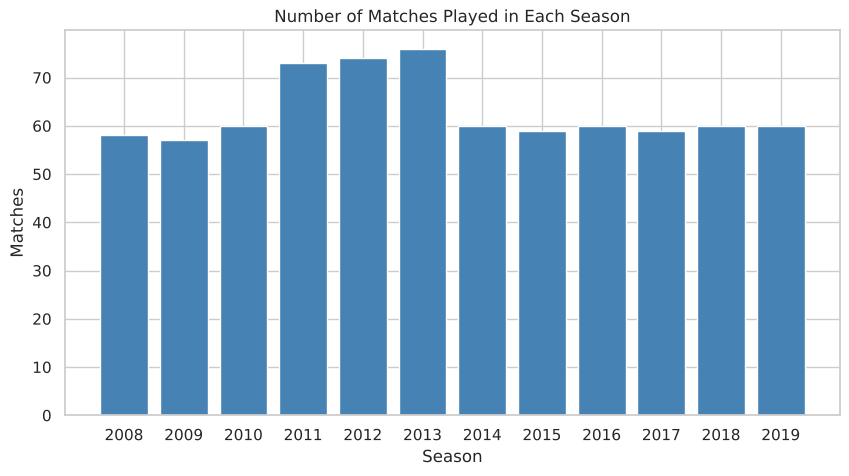

In [152]:
matches_per_season = matches['season'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.bar(matches_per_season.index.astype(str), matches_per_season.values, color='steelblue')
plt.title('Number of Matches Played in Each Season')
plt.xlabel('Season')
plt.ylabel('Matches')
plt.show()

### Question 152
Create a Matplotlib line chart showing the number of matches played in each season.

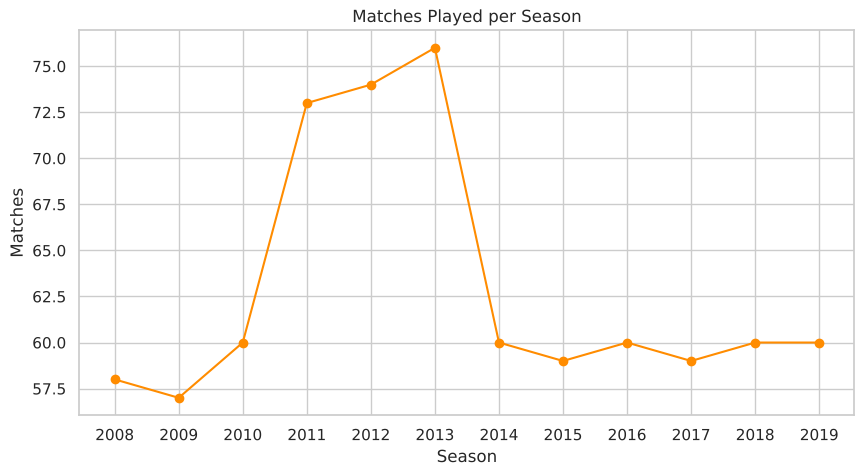

In [153]:
plt.figure(figsize=(10, 5))
plt.plot(matches_per_season.index, matches_per_season.values, marker='o', color='darkorange')
plt.title('Matches Played per Season')
plt.xlabel('Season')
plt.ylabel('Matches')
plt.xticks(matches_per_season.index)
plt.show()

### Question 153
Create a bar chart of the top 10 teams by total match wins.

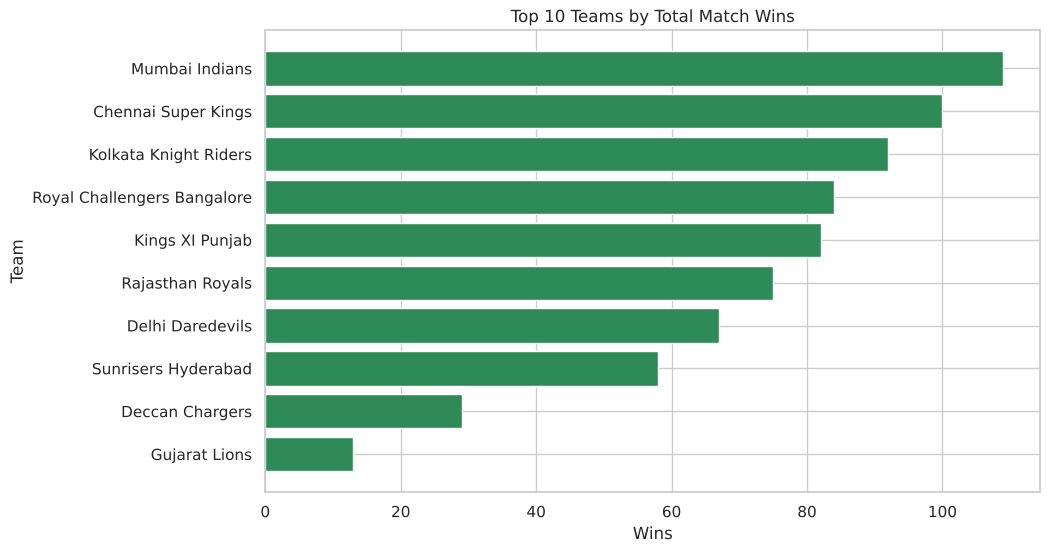

In [154]:
top_wins = decided['winner'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_wins.index[::-1], top_wins.values[::-1], color='seagreen')
plt.title('Top 10 Teams by Total Match Wins')
plt.xlabel('Wins')
plt.ylabel('Team')
plt.show()

### Question 154
Create a bar chart of the top 10 teams by total toss wins.

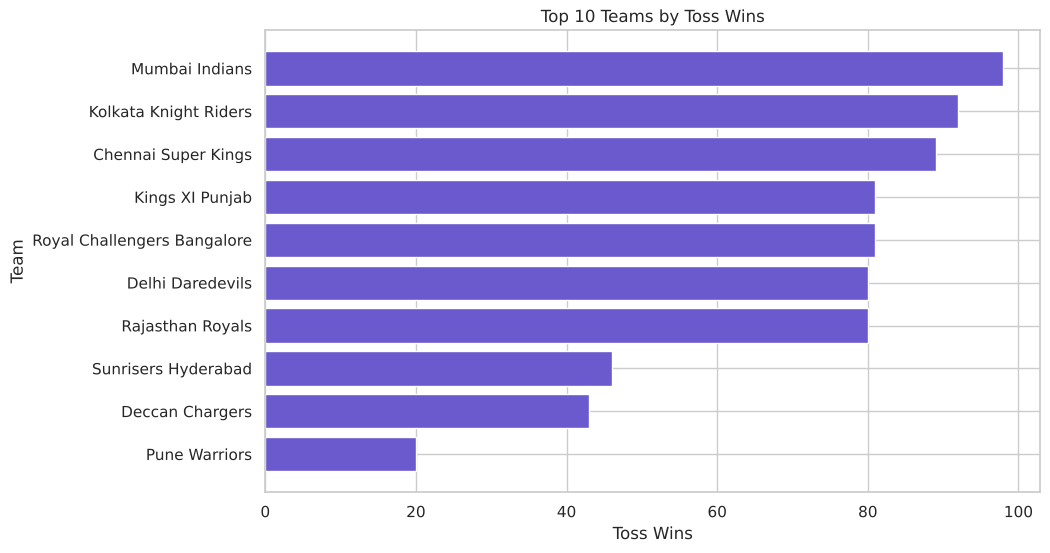

In [155]:
top_toss = matches['toss_winner'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_toss.index[::-1], top_toss.values[::-1], color='slateblue')
plt.title('Top 10 Teams by Toss Wins')
plt.xlabel('Toss Wins')
plt.ylabel('Team')
plt.show()

### Question 155
Create a pie chart showing the proportion of `bat` vs `field` toss decisions.

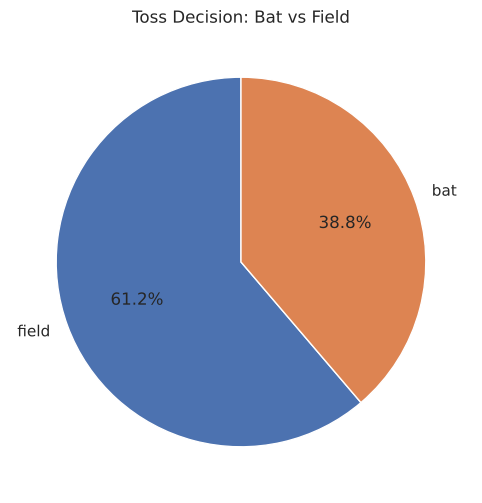

In [156]:
toss_dec = matches['toss_decision'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(toss_dec.values, labels=toss_dec.index, autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#DD8452'])
plt.title('Toss Decision: Bat vs Field')
plt.show()

### Question 156
Create a bar chart showing the top 10 players by Player of the Match awards.

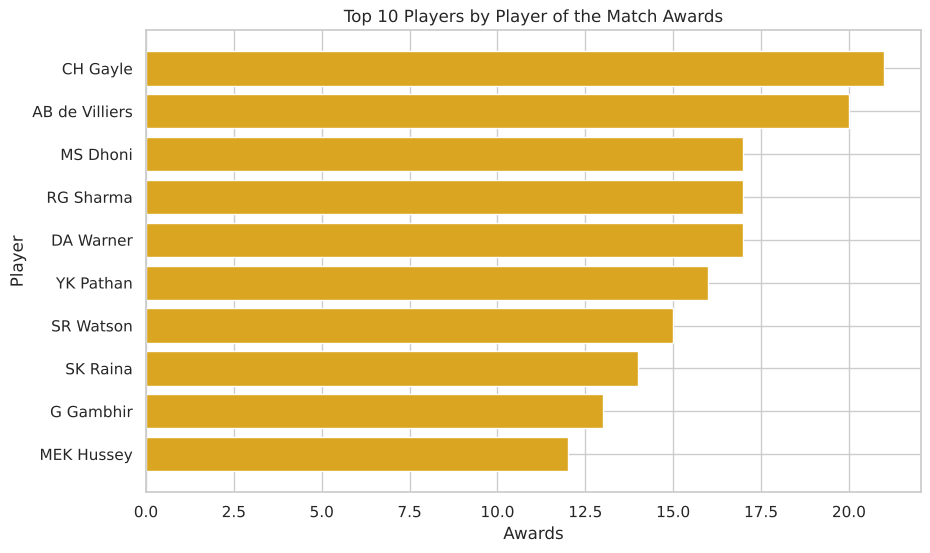

In [157]:
top_pom = matches['player_of_match'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_pom.index[::-1], top_pom.values[::-1], color='goldenrod')
plt.title('Top 10 Players by Player of the Match Awards')
plt.xlabel('Awards')
plt.ylabel('Player')
plt.show()

### Question 157
Create a bar chart showing the top 10 cities by number of matches hosted.

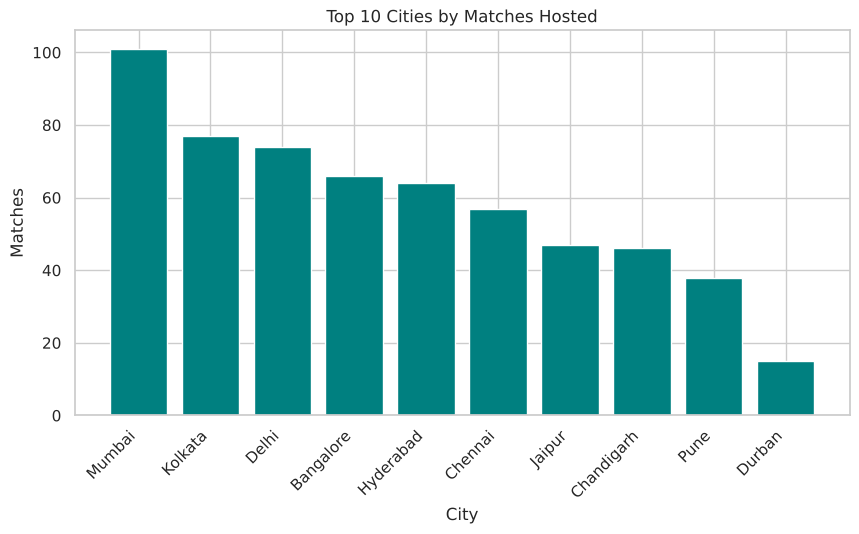

In [158]:
top_cities = matches['city'].value_counts().head(10)
plt.figure(figsize=(10, 5))
plt.bar(top_cities.index, top_cities.values, color='teal')
plt.title('Top 10 Cities by Matches Hosted')
plt.xlabel('City')
plt.ylabel('Matches')
plt.xticks(rotation=45, ha='right')
plt.show()

### Question 158
Create a bar chart showing the top 10 venues by number of matches hosted.

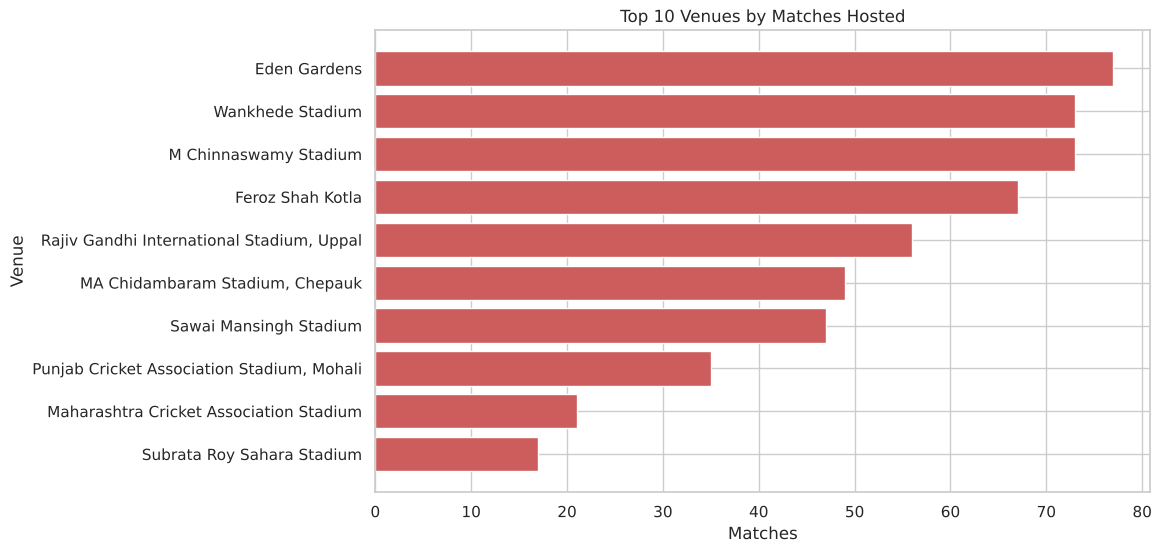

In [159]:
top_venues = matches['venue'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_venues.index[::-1], top_venues.values[::-1], color='indianred')
plt.title('Top 10 Venues by Matches Hosted')
plt.xlabel('Matches')
plt.ylabel('Venue')
plt.show()

### Question 159
Create a histogram of `win_by_runs` values greater than 0.

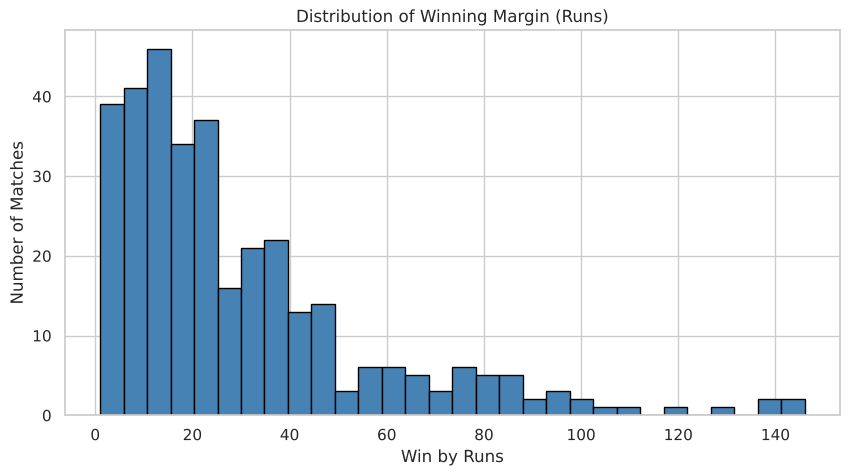

In [160]:
plt.figure(figsize=(10, 5))
plt.hist(matches.loc[matches['win_by_runs'] > 0, 'win_by_runs'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Winning Margin (Runs)')
plt.xlabel('Win by Runs')
plt.ylabel('Number of Matches')
plt.show()

### Question 160
Create a histogram of `win_by_wickets` values greater than 0.

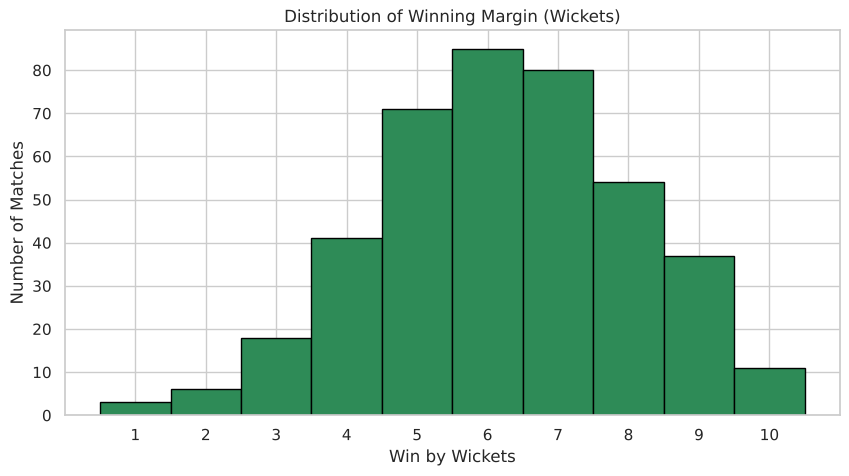

In [161]:
plt.figure(figsize=(10, 5))
plt.hist(matches.loc[matches['win_by_wickets'] > 0, 'win_by_wickets'], bins=range(1, 12), color='seagreen', edgecolor='black', align='left')
plt.title('Distribution of Winning Margin (Wickets)')
plt.xlabel('Win by Wickets')
plt.ylabel('Number of Matches')
plt.xticks(range(1, 11))
plt.show()

### Question 161
Create a scatter plot of `win_by_runs` vs `win_by_wickets` for all matches.

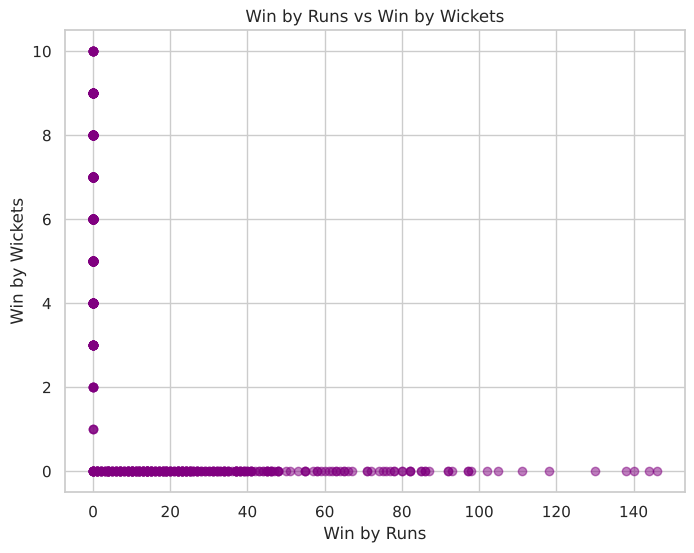

In [162]:
plt.figure(figsize=(8, 6))
plt.scatter(matches['win_by_runs'], matches['win_by_wickets'], alpha=0.5, color='purple')
plt.title('Win by Runs vs Win by Wickets')
plt.xlabel('Win by Runs')
plt.ylabel('Win by Wickets')
plt.show()

### Question 162
Create a line chart showing the number of matches won by `Mumbai Indians` in each season.

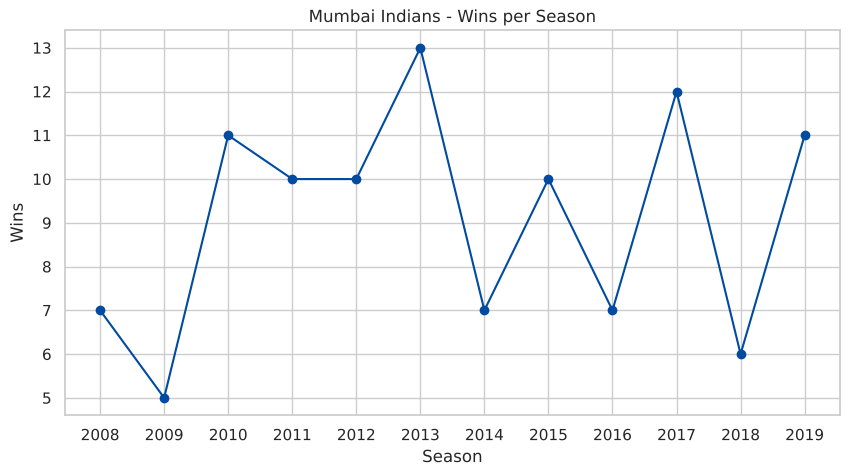

In [163]:
all_seasons = sorted(matches['season'].unique())
mi_wins = decided[decided['winner'] == 'Mumbai Indians'].groupby('season').size().reindex(all_seasons, fill_value=0)
plt.figure(figsize=(10, 5))
plt.plot(mi_wins.index, mi_wins.values, marker='o', color='#004BA0')
plt.title('Mumbai Indians - Wins per Season')
plt.xlabel('Season')
plt.ylabel('Wins')
plt.xticks(all_seasons)
plt.show()

### Question 163
Create a line chart showing the number of matches won by `Chennai Super Kings` in each season.

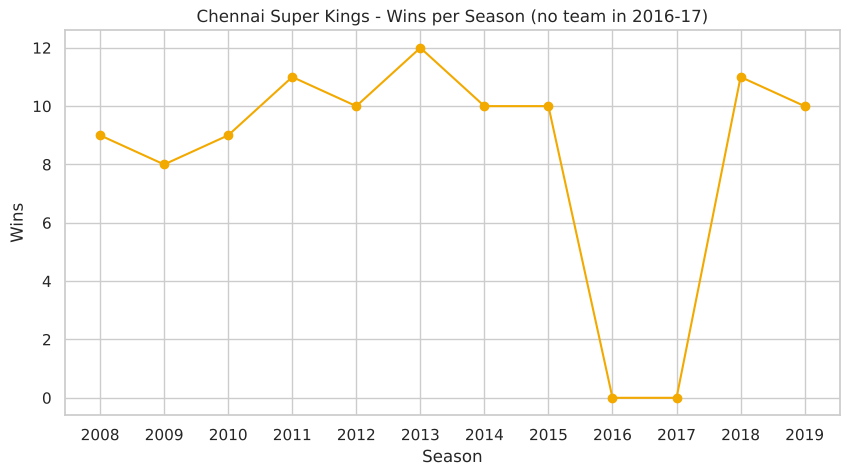

In [164]:
csk_wins = decided[decided['winner'] == 'Chennai Super Kings'].groupby('season').size().reindex(all_seasons, fill_value=0)
plt.figure(figsize=(10, 5))
plt.plot(csk_wins.index, csk_wins.values, marker='o', color='#F2A900')
plt.title('Chennai Super Kings - Wins per Season (no team in 2016-17)')
plt.xlabel('Season')
plt.ylabel('Wins')
plt.xticks(all_seasons)
plt.show()

### Question 164
Create a bar chart comparing the number of matches where toss winner = match winner and toss winner != match winner.

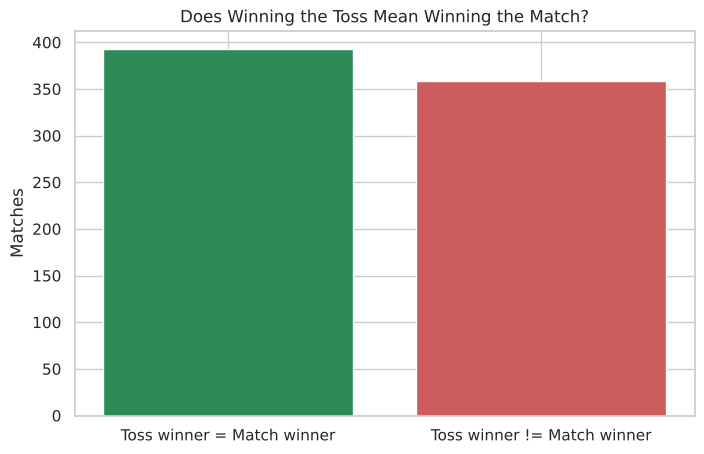

In [165]:
toss_compare = pd.Series({
    'Toss winner = Match winner': (decided['toss_winner'] == decided['winner']).sum(),
    'Toss winner != Match winner': (decided['toss_winner'] != decided['winner']).sum(),
})
plt.figure(figsize=(8, 5))
plt.bar(toss_compare.index, toss_compare.values, color=['seagreen', 'indianred'])
plt.title('Does Winning the Toss Mean Winning the Match?')
plt.ylabel('Matches')
plt.show()

### Question 165
Create a bar chart showing the total runs scored by the top 10 batting teams.

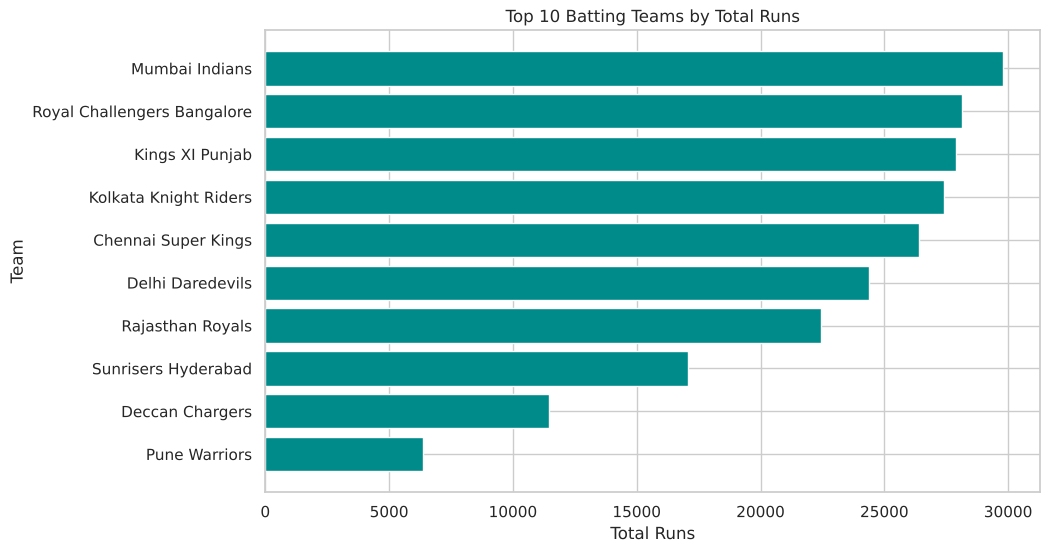

In [166]:
top_bat_teams = deliveries.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_bat_teams.index[::-1], top_bat_teams.values[::-1], color='darkcyan')
plt.title('Top 10 Batting Teams by Total Runs')
plt.xlabel('Total Runs')
plt.ylabel('Team')
plt.show()

### Question 166
Create a bar chart showing the top 10 batsmen by total runs.

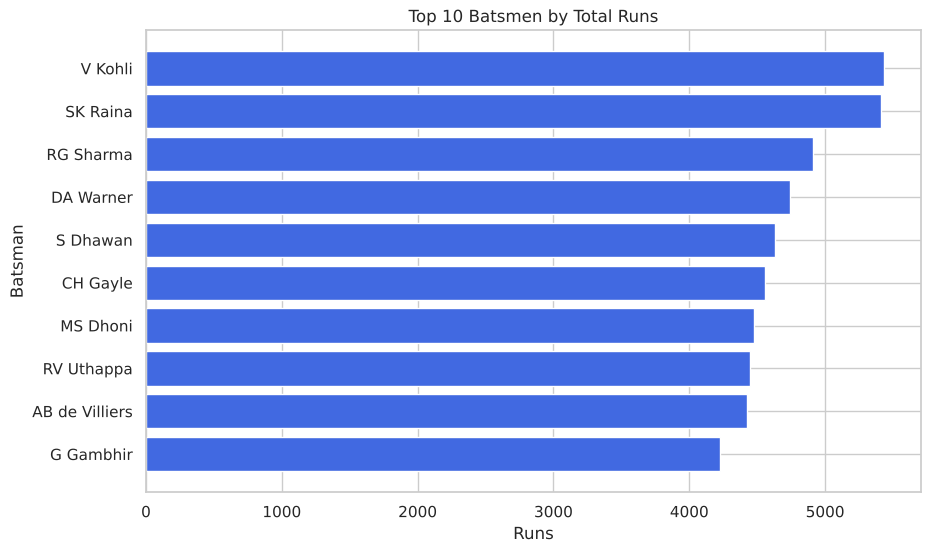

In [167]:
plt.figure(figsize=(10, 6))
plt.barh(top10_batsmen.index[::-1], top10_batsmen.values[::-1], color='royalblue')
plt.title('Top 10 Batsmen by Total Runs')
plt.xlabel('Runs')
plt.ylabel('Batsman')
plt.show()

### Question 167
Create a bar chart showing the top 10 batsmen by number of sixes.

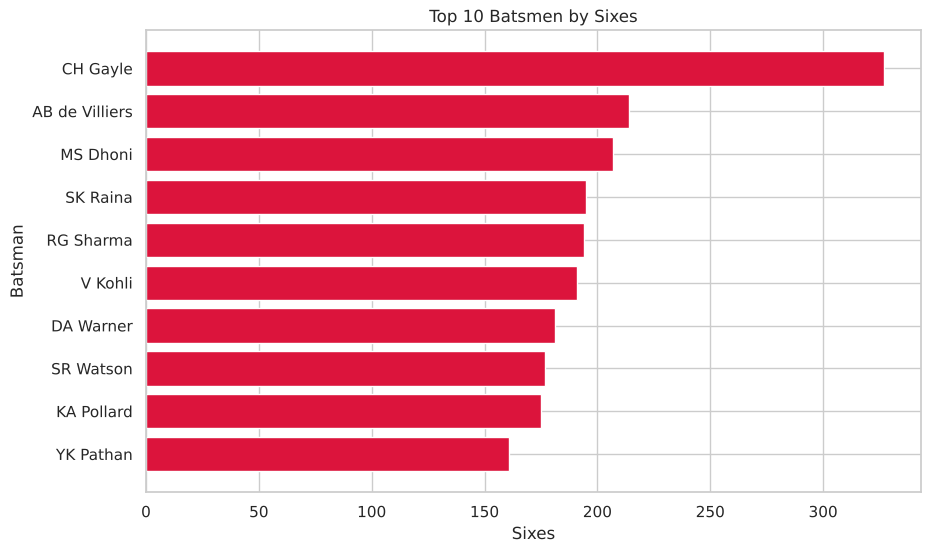

In [168]:
top_sixes = deliveries[deliveries['batsman_runs'] == 6].groupby('batsman').size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_sixes.index[::-1], top_sixes.values[::-1], color='crimson')
plt.title('Top 10 Batsmen by Sixes')
plt.xlabel('Sixes')
plt.ylabel('Batsman')
plt.show()

### Question 168
Create a bar chart showing the top 10 batsmen by number of fours.

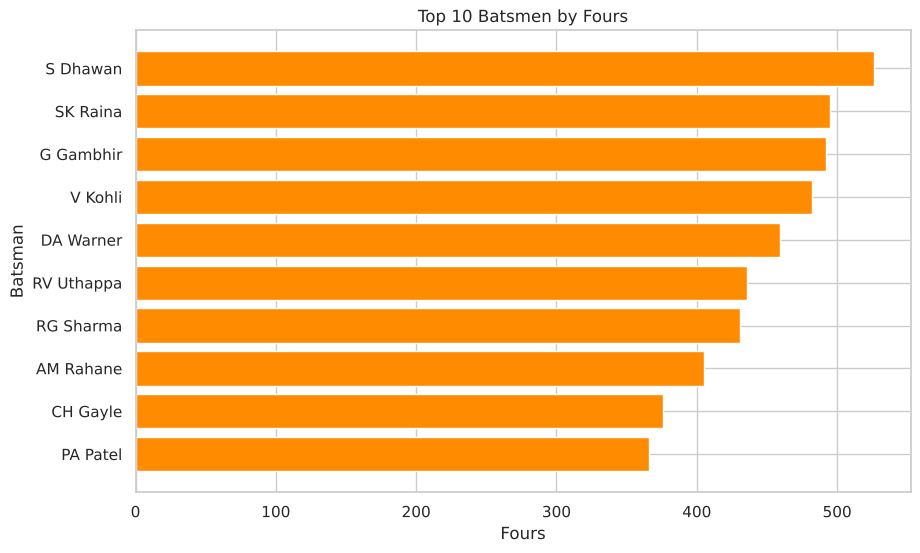

In [169]:
top_fours = deliveries[deliveries['batsman_runs'] == 4].groupby('batsman').size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_fours.index[::-1], top_fours.values[::-1], color='darkorange')
plt.title('Top 10 Batsmen by Fours')
plt.xlabel('Fours')
plt.ylabel('Batsman')
plt.show()

### Question 169
Create a histogram of `batsman_runs` for all deliveries.

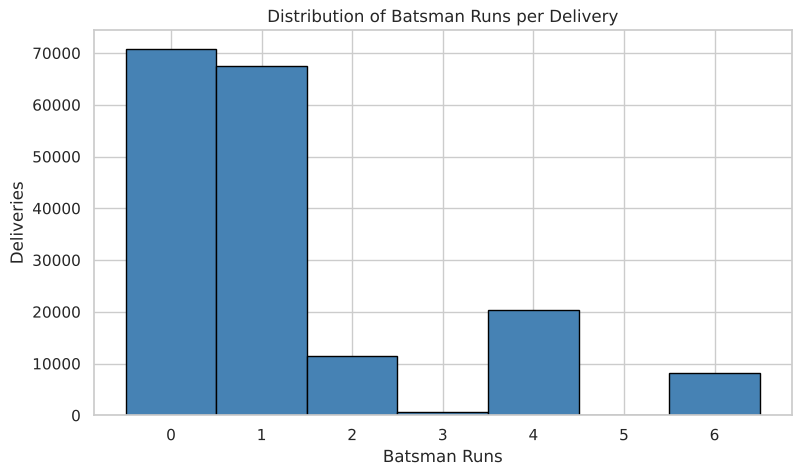

In [170]:
plt.figure(figsize=(9, 5))
plt.hist(deliveries['batsman_runs'], bins=range(0, 8), align='left', color='steelblue', edgecolor='black')
plt.title('Distribution of Batsman Runs per Delivery')
plt.xlabel('Batsman Runs')
plt.ylabel('Deliveries')
plt.xticks(range(0, 7))
plt.show()

### Question 170
Create a histogram of `total_runs` per delivery.

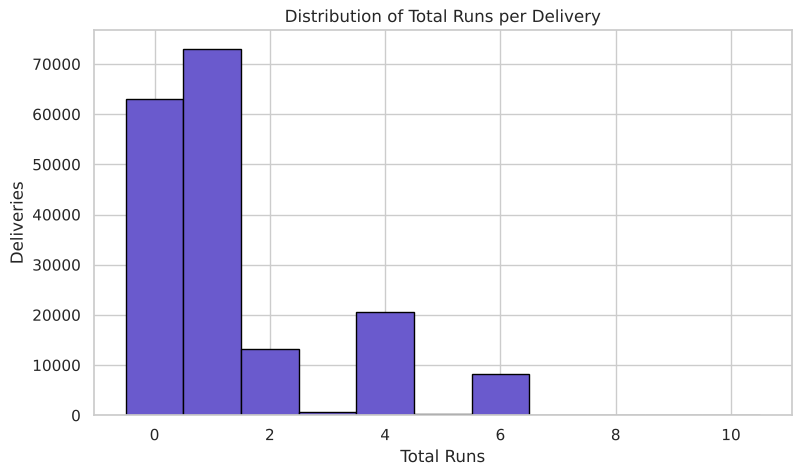

In [171]:
plt.figure(figsize=(9, 5))
plt.hist(deliveries['total_runs'], bins=range(0, deliveries['total_runs'].max() + 2), align='left', color='slateblue', edgecolor='black')
plt.title('Distribution of Total Runs per Delivery')
plt.xlabel('Total Runs')
plt.ylabel('Deliveries')
plt.show()

### Question 171
After merging both datasets, create a line chart of total runs scored in each season.

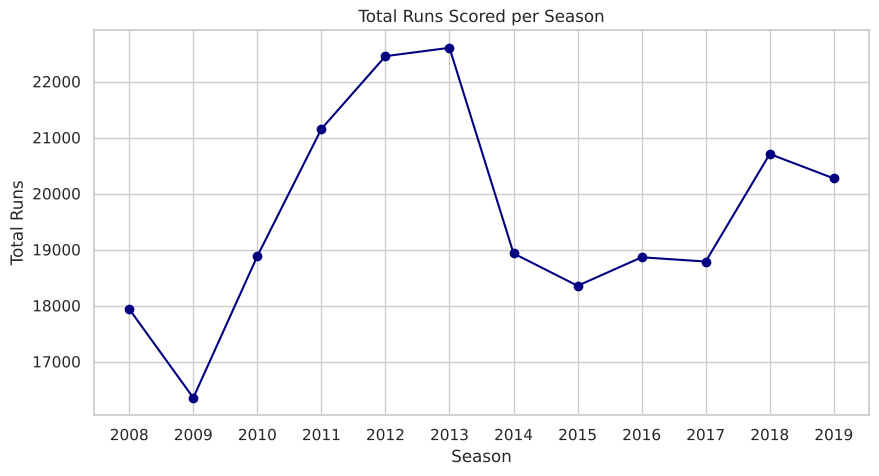

In [172]:
season_runs = merged.groupby('season')['total_runs'].sum()
plt.figure(figsize=(10, 5))
plt.plot(season_runs.index, season_runs.values, marker='o', color='navy')
plt.title('Total Runs Scored per Season')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(season_runs.index)
plt.show()

### Question 172
After merging both datasets, create a bar chart of total sixes in each season.

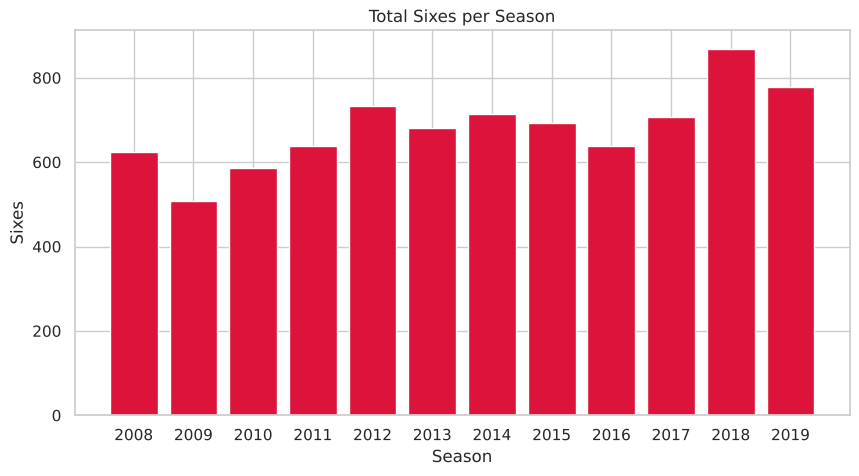

In [173]:
season_sixes = merged[merged['batsman_runs'] == 6].groupby('season').size()
plt.figure(figsize=(10, 5))
plt.bar(season_sixes.index.astype(str), season_sixes.values, color='crimson')
plt.title('Total Sixes per Season')
plt.xlabel('Season')
plt.ylabel('Sixes')
plt.show()

### Question 173
After merging both datasets, create a bar chart of total fours in each season.

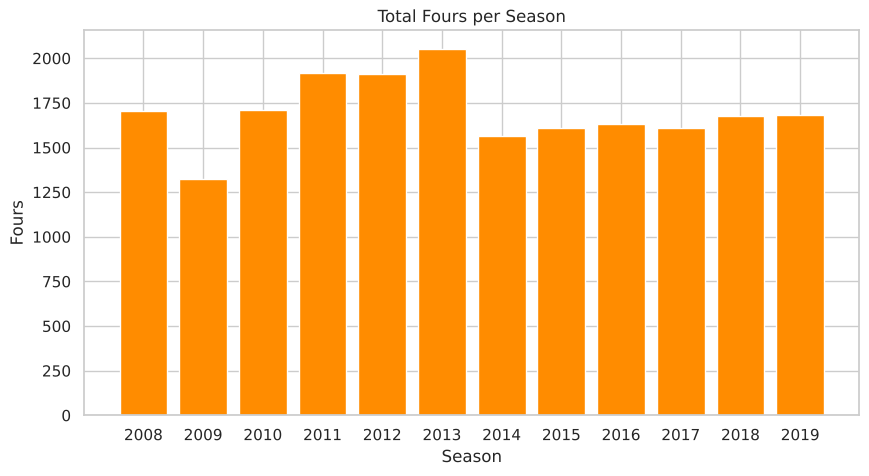

In [174]:
season_fours = merged[merged['batsman_runs'] == 4].groupby('season').size()
plt.figure(figsize=(10, 5))
plt.bar(season_fours.index.astype(str), season_fours.values, color='darkorange')
plt.title('Total Fours per Season')
plt.xlabel('Season')
plt.ylabel('Fours')
plt.show()

### Question 174
After merging both datasets, create a line chart of total extras in each season.

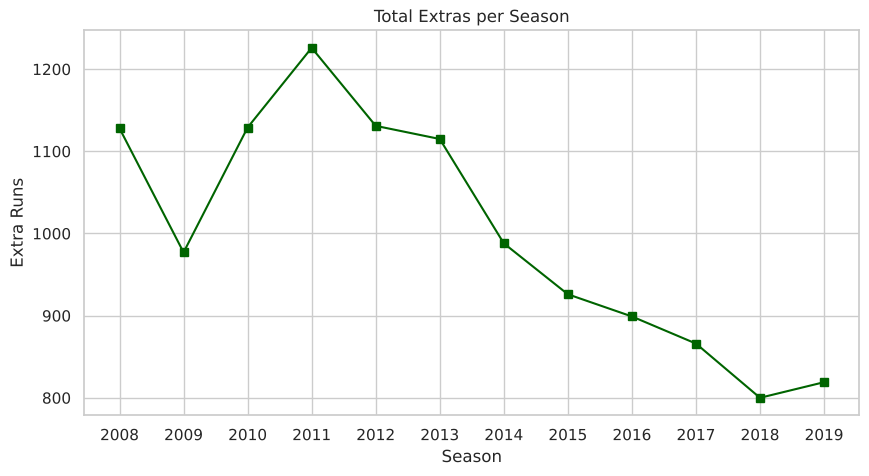

In [175]:
season_extras = merged.groupby('season')['extra_runs'].sum()
plt.figure(figsize=(10, 5))
plt.plot(season_extras.index, season_extras.values, marker='s', color='darkgreen')
plt.title('Total Extras per Season')
plt.xlabel('Season')
plt.ylabel('Extra Runs')
plt.xticks(season_extras.index)
plt.show()

### Question 175
Create a scatter plot for the top 20 batsmen where x = total runs and y = number of sixes.

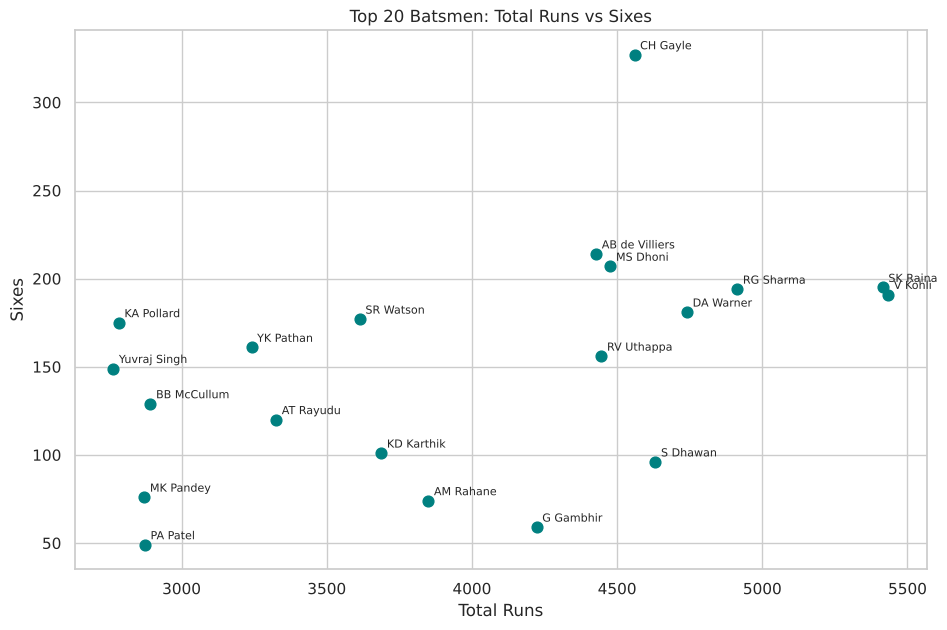

In [176]:
all_sixes = deliveries[deliveries['batsman_runs'] == 6].groupby('batsman').size()
top20 = pd.DataFrame({'runs': batsman_runs.head(20)})
top20['sixes'] = all_sixes.reindex(top20.index).fillna(0)
plt.figure(figsize=(11, 7))
plt.scatter(top20['runs'], top20['sixes'], s=60, color='teal')
for name, row in top20.iterrows():
    plt.annotate(name, (row['runs'], row['sixes']), fontsize=8, xytext=(4, 4), textcoords='offset points')
plt.title('Top 20 Batsmen: Total Runs vs Sixes')
plt.xlabel('Total Runs')
plt.ylabel('Sixes')
plt.show()

### Question 176
Create a scatter plot for bowlers where x = number of deliveries bowled and y = recorded dismissals (exclude run outs).

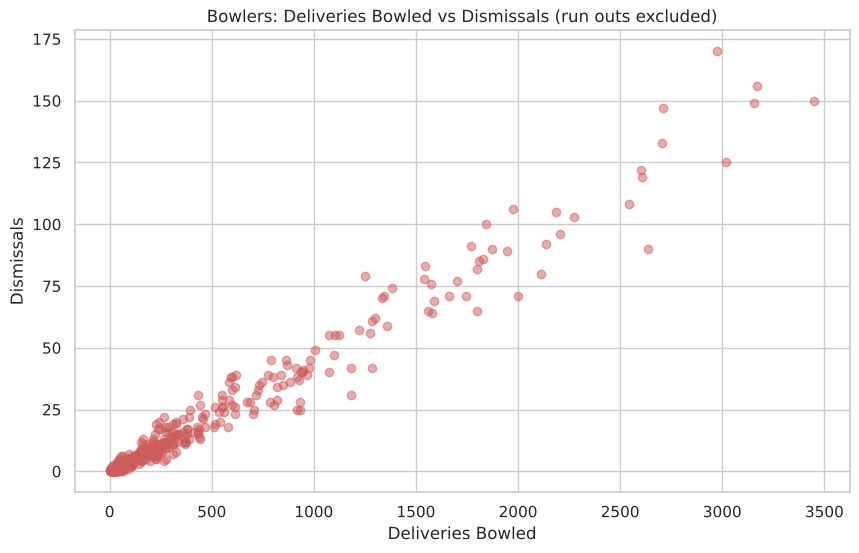

In [177]:
balls_bowled = deliveries.groupby('bowler').size()
bowler_dismissals = deliveries[deliveries['player_dismissed'].notna() & (deliveries['dismissal_kind'] != 'run out')].groupby('bowler').size()
bowler_stats = pd.DataFrame({'deliveries': balls_bowled, 'dismissals': bowler_dismissals}).fillna(0)
plt.figure(figsize=(10, 6))
plt.scatter(bowler_stats['deliveries'], bowler_stats['dismissals'], alpha=0.5, color='indianred')
plt.title('Bowlers: Deliveries Bowled vs Dismissals (run outs excluded)')
plt.xlabel('Deliveries Bowled')
plt.ylabel('Dismissals')
plt.show()

### Question 177
Create a 1x2 subplot: matches per season on the left and total team wins on the right.

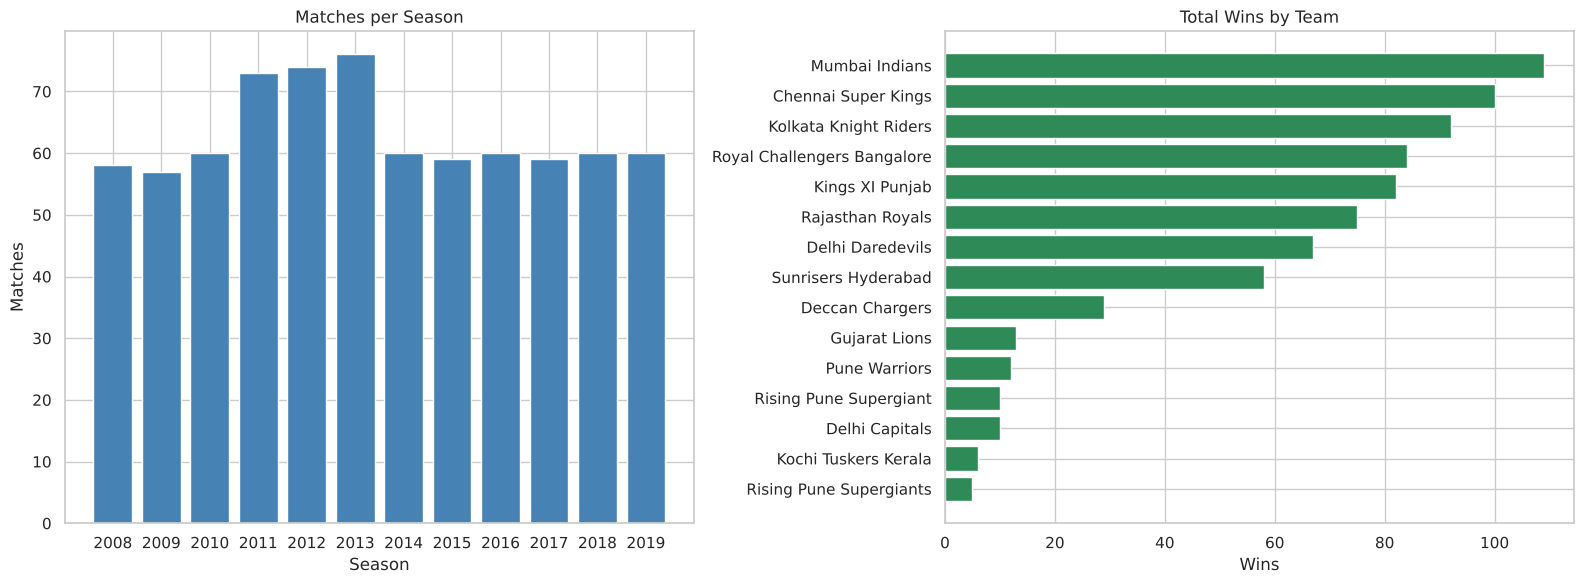

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].bar(matches_per_season.index.astype(str), matches_per_season.values, color='steelblue')
axes[0].set_title('Matches per Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Matches')
team_wins_all = decided['winner'].value_counts()
axes[1].barh(team_wins_all.index[::-1], team_wins_all.values[::-1], color='seagreen')
axes[1].set_title('Total Wins by Team')
axes[1].set_xlabel('Wins')
plt.tight_layout()
plt.show()

### Question 178
Create a 2x2 subplot containing: top teams by wins, top venues by matches, top batsmen by runs, and top batsmen by sixes.

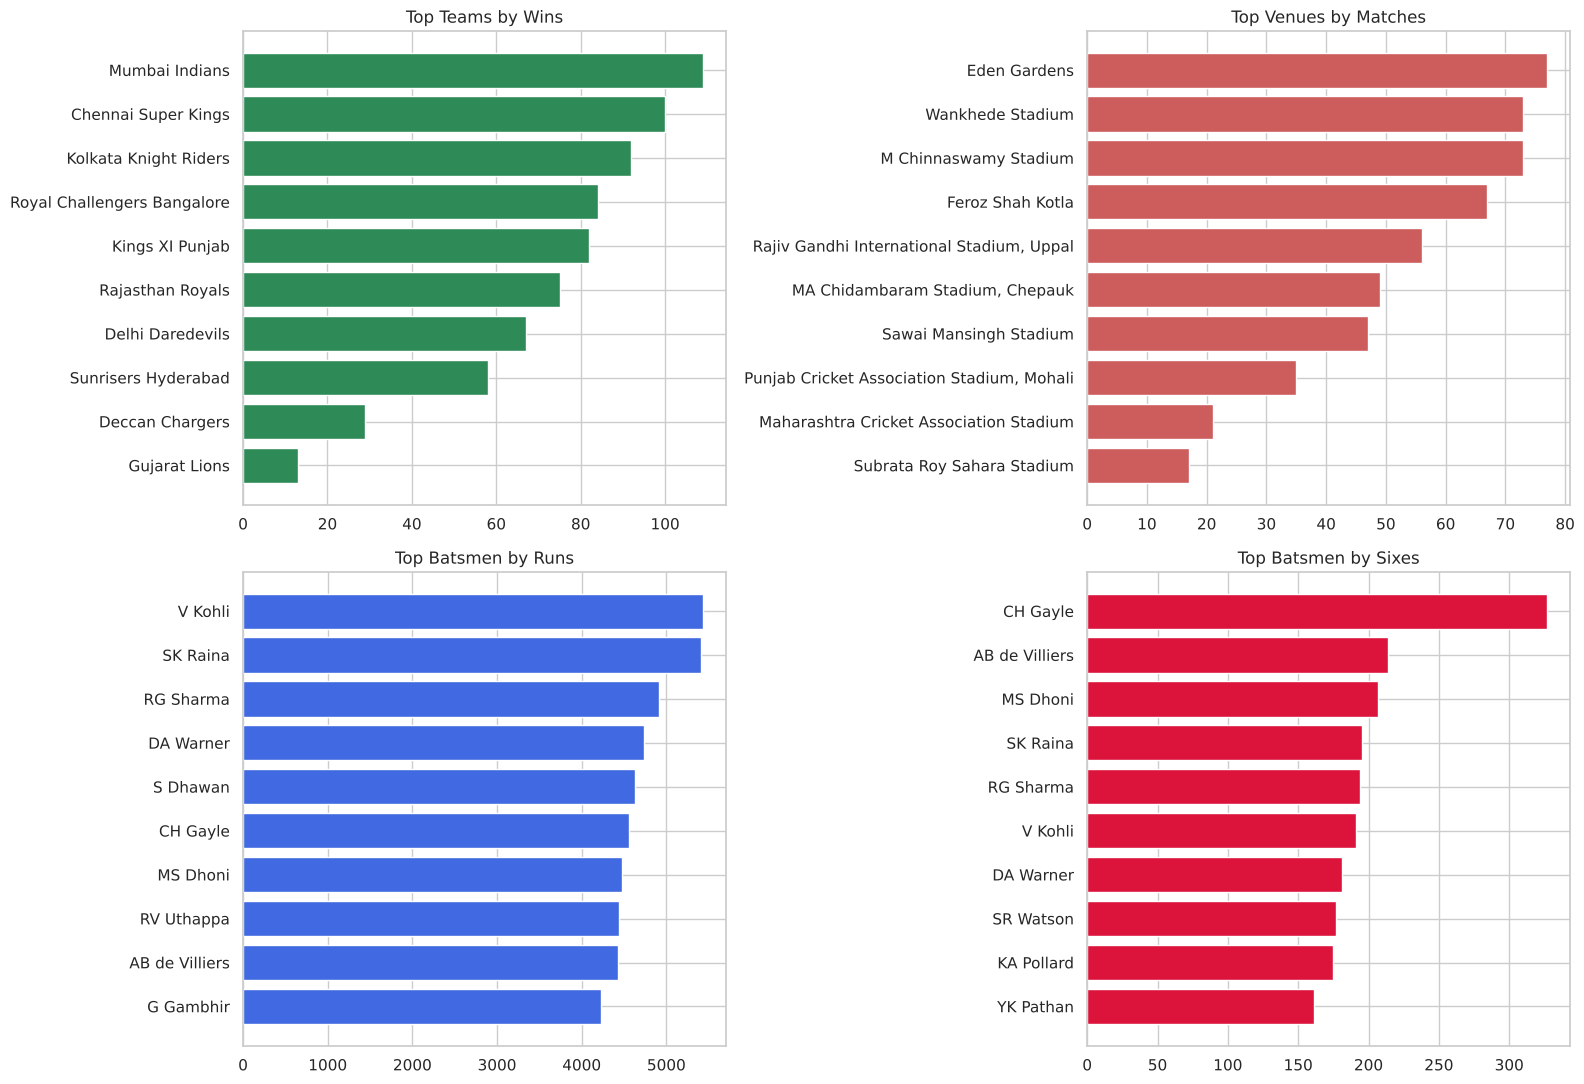

In [179]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes[0, 0].barh(top_wins.index[::-1], top_wins.values[::-1], color='seagreen')
axes[0, 0].set_title('Top Teams by Wins')
axes[0, 1].barh(top_venues.index[::-1], top_venues.values[::-1], color='indianred')
axes[0, 1].set_title('Top Venues by Matches')
axes[1, 0].barh(top10_batsmen.index[::-1], top10_batsmen.values[::-1], color='royalblue')
axes[1, 0].set_title('Top Batsmen by Runs')
axes[1, 1].barh(top_sixes.index[::-1], top_sixes.values[::-1], color='crimson')
axes[1, 1].set_title('Top Batsmen by Sixes')
plt.tight_layout()
plt.show()

### Question 179
Create a 1x2 subplot comparing the distributions of `win_by_runs` and `win_by_wickets`.

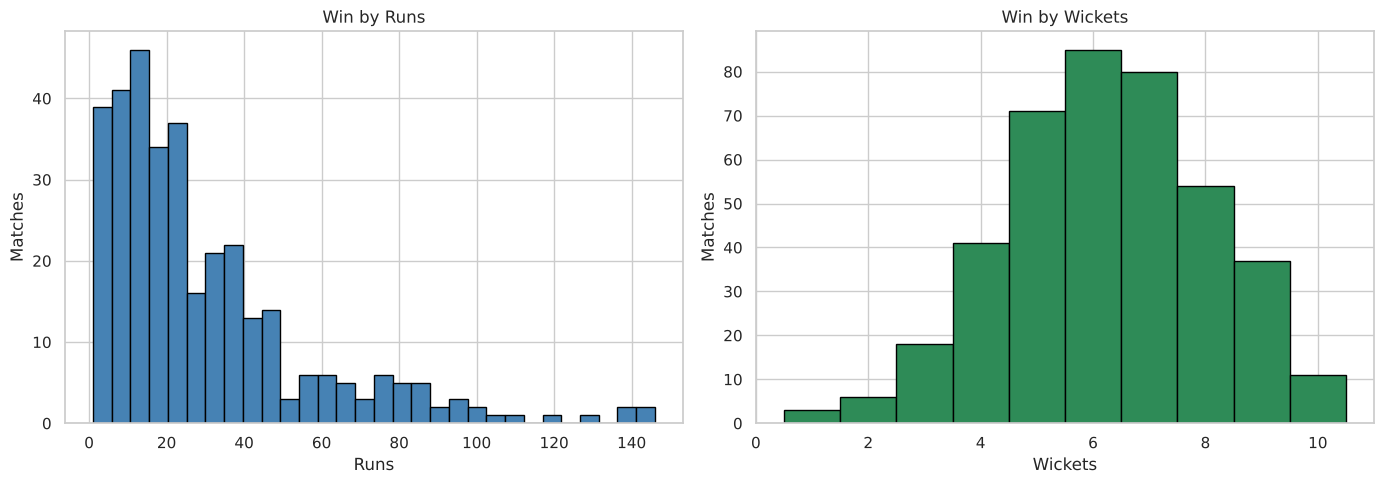

In [180]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(matches.loc[matches['win_by_runs'] > 0, 'win_by_runs'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Win by Runs')
axes[0].set_xlabel('Runs')
axes[0].set_ylabel('Matches')
axes[1].hist(matches.loc[matches['win_by_wickets'] > 0, 'win_by_wickets'], bins=range(1, 12), align='left', color='seagreen', edgecolor='black')
axes[1].set_title('Win by Wickets')
axes[1].set_xlabel('Wickets')
axes[1].set_ylabel('Matches')
plt.tight_layout()
plt.show()

### Question 180
Create a multi-plot figure showing season-wise total runs, sixes, fours, and extras using four subplots.

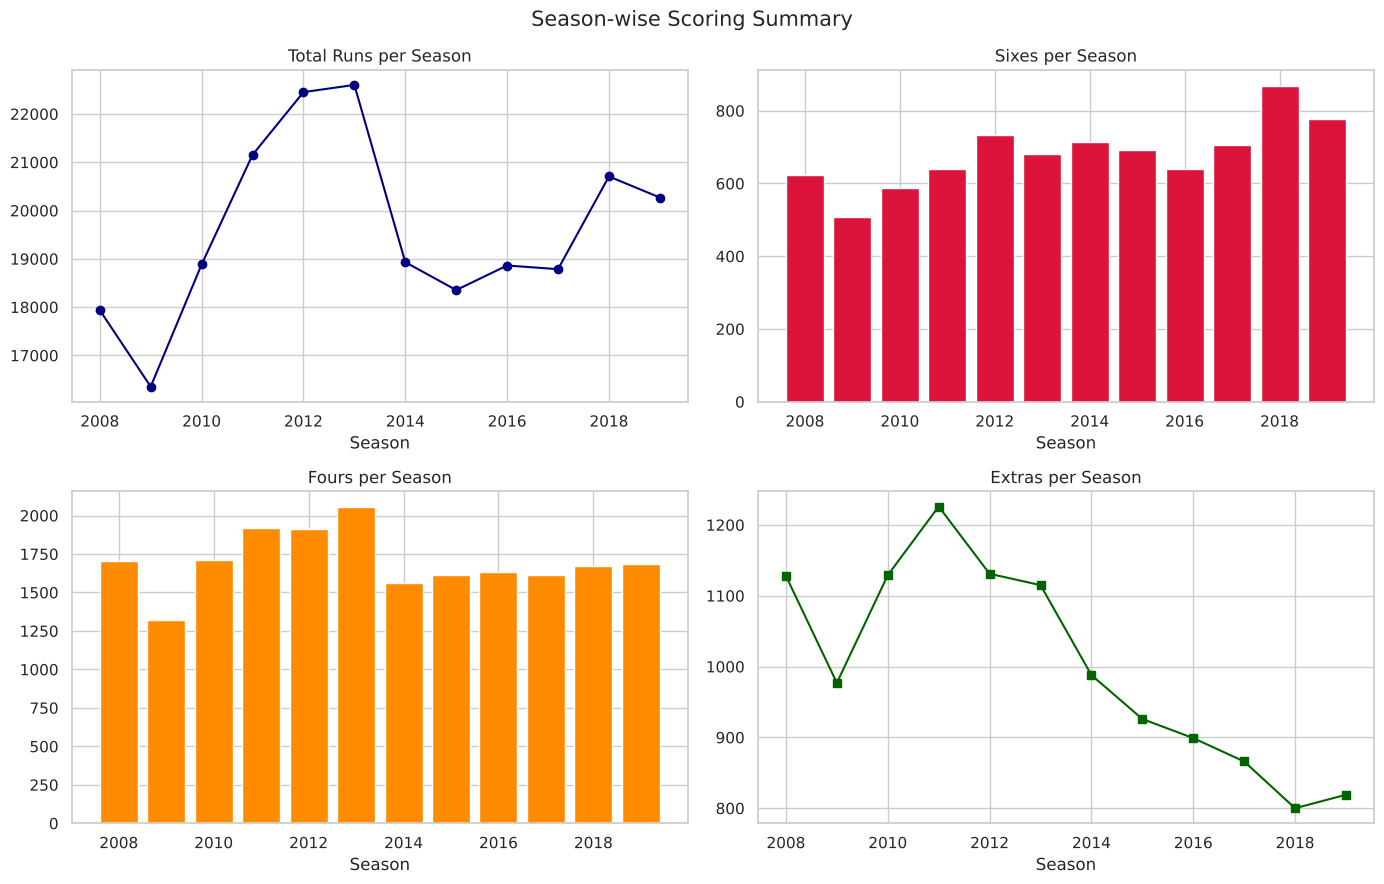

In [181]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(season_runs.index, season_runs.values, marker='o', color='navy')
axes[0, 0].set_title('Total Runs per Season')
axes[0, 1].bar(season_sixes.index, season_sixes.values, color='crimson')
axes[0, 1].set_title('Sixes per Season')
axes[1, 0].bar(season_fours.index, season_fours.values, color='darkorange')
axes[1, 0].set_title('Fours per Season')
axes[1, 1].plot(season_extras.index, season_extras.values, marker='s', color='darkgreen')
axes[1, 1].set_title('Extras per Season')
for ax in axes.flat:
    ax.set_xlabel('Season')
plt.suptitle('Season-wise Scoring Summary', fontsize=15)
plt.tight_layout()
plt.show()

# Section H - Seaborn Visualization (20 Questions)

### Question 181
Create a Seaborn `countplot` for `toss_decision`.

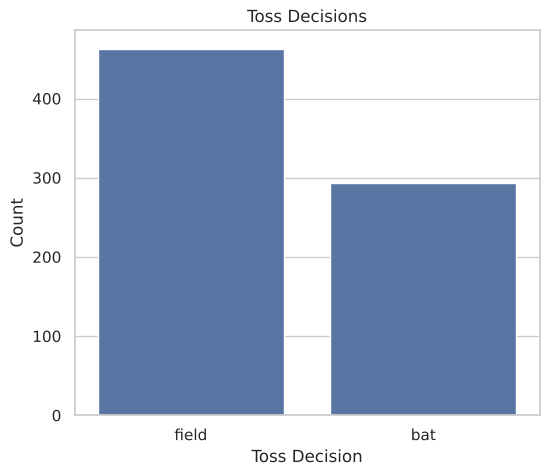

In [182]:
plt.figure(figsize=(6, 5))
sns.countplot(data=matches, x='toss_decision')
plt.title('Toss Decisions')
plt.xlabel('Toss Decision')
plt.ylabel('Count')
plt.show()

### Question 182
Create a Seaborn `countplot` for the `result` column in `matches`.

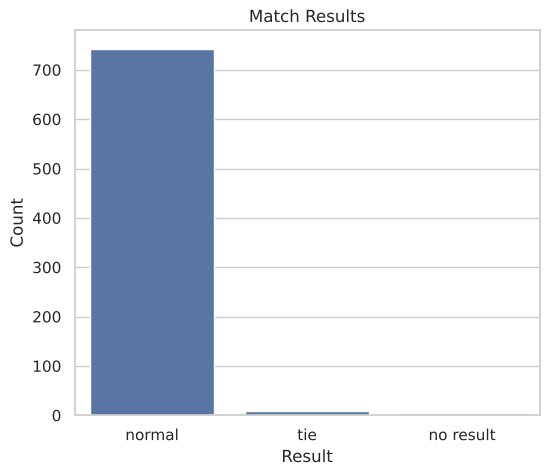

In [183]:
plt.figure(figsize=(6, 5))
sns.countplot(data=matches, x='result')
plt.title('Match Results')
plt.xlabel('Result')
plt.ylabel('Count')
plt.show()

### Question 183
Create a Seaborn `countplot` showing the number of matches in each season.

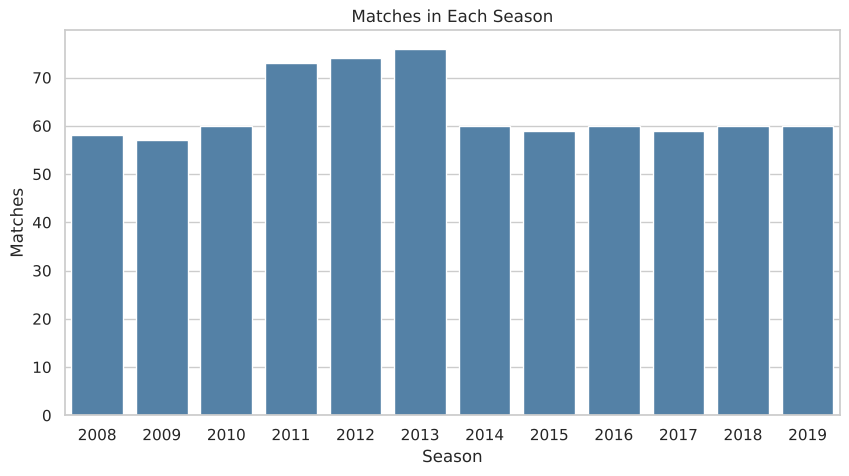

In [184]:
plt.figure(figsize=(10, 5))
sns.countplot(data=matches, x='season', color='steelblue')
plt.title('Matches in Each Season')
plt.xlabel('Season')
plt.ylabel('Matches')
plt.show()

### Question 184
Create a Seaborn `barplot` for the top 10 teams by match wins.

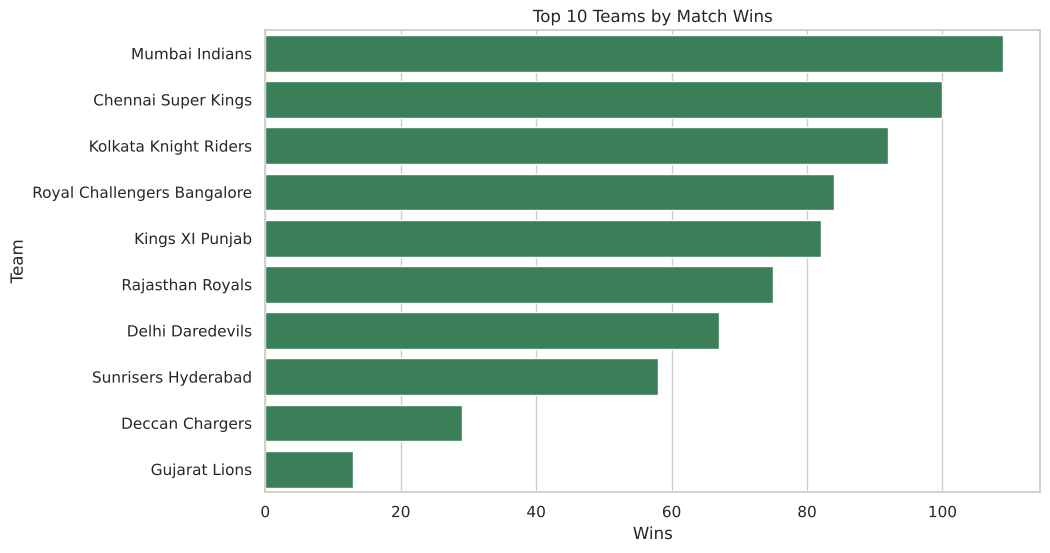

In [185]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_wins.values, y=top_wins.index, color='seagreen')
plt.title('Top 10 Teams by Match Wins')
plt.xlabel('Wins')
plt.ylabel('Team')
plt.show()

### Question 185
Create a Seaborn `barplot` for the top 10 venues by number of matches.

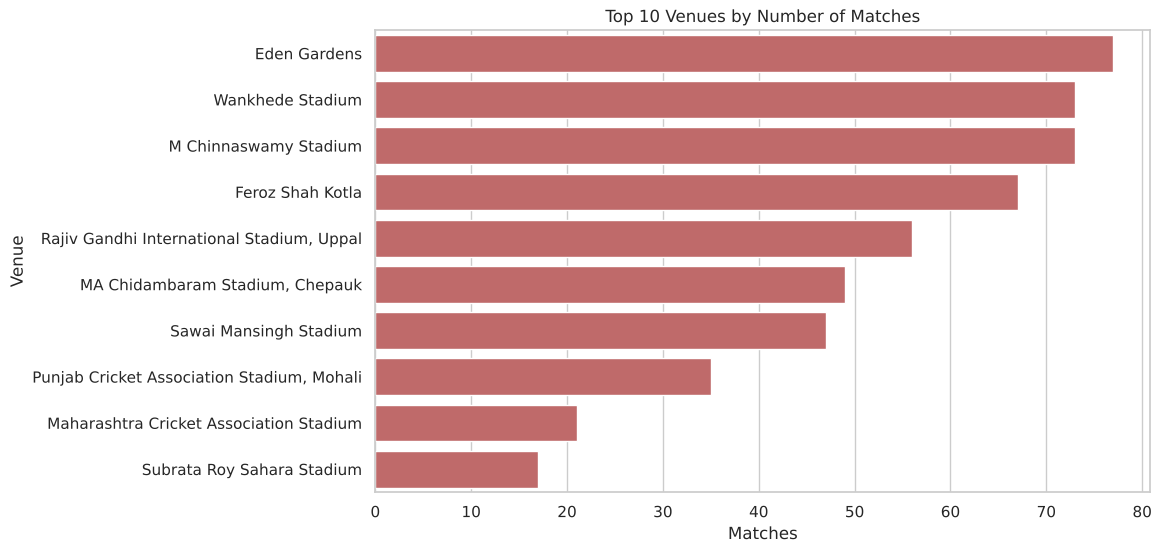

In [186]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_venues.values, y=top_venues.index, color='indianred')
plt.title('Top 10 Venues by Number of Matches')
plt.xlabel('Matches')
plt.ylabel('Venue')
plt.show()

### Question 186
Create a Seaborn `barplot` for the top 10 Player of the Match award winners.

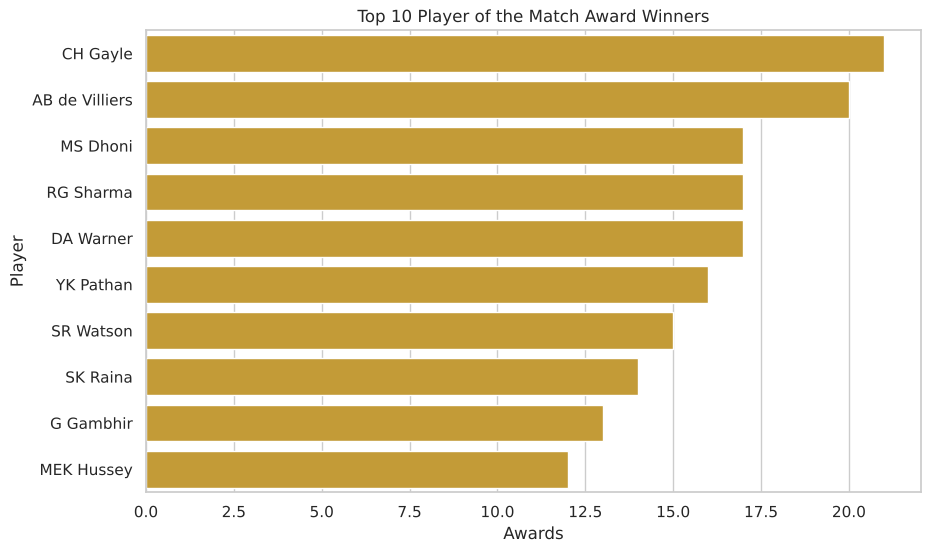

In [187]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_pom.values, y=top_pom.index, color='goldenrod')
plt.title('Top 10 Player of the Match Award Winners')
plt.xlabel('Awards')
plt.ylabel('Player')
plt.show()

### Question 187
Create a Seaborn `lineplot` showing matches played per season.

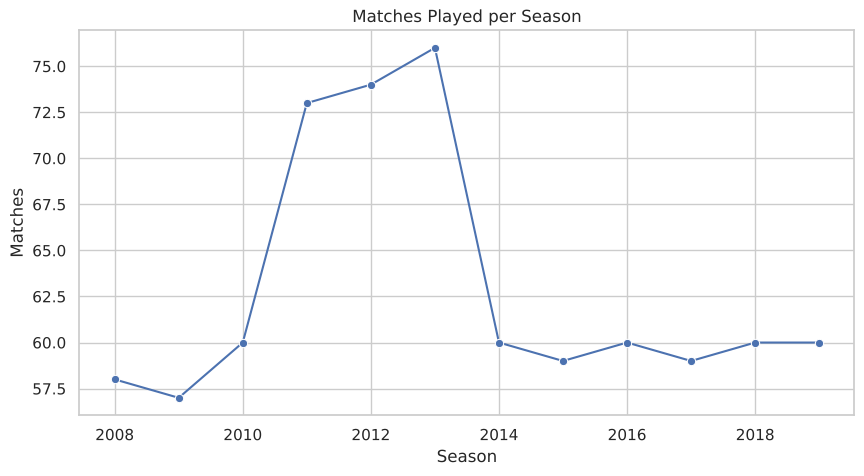

In [188]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=matches_per_season.index, y=matches_per_season.values, marker='o')
plt.title('Matches Played per Season')
plt.xlabel('Season')
plt.ylabel('Matches')
plt.show()

### Question 188
After merging the datasets, create a Seaborn `lineplot` showing total runs per season.

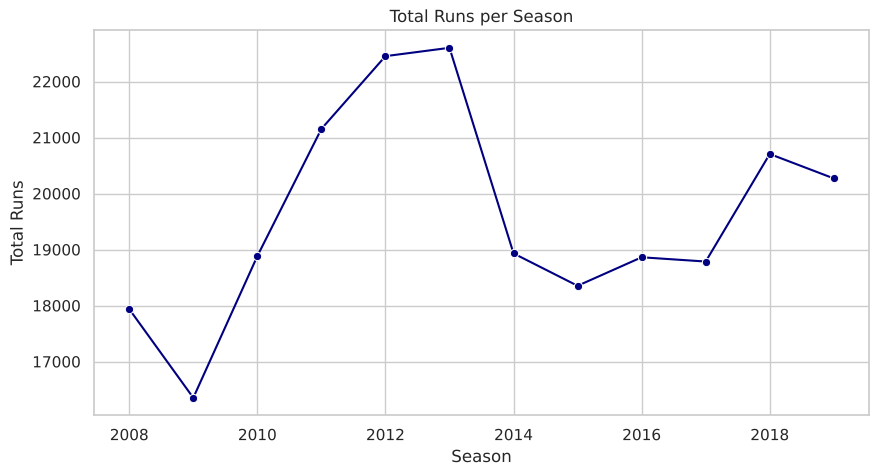

In [189]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=season_runs.index, y=season_runs.values, marker='o', color='navy')
plt.title('Total Runs per Season')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.show()

### Question 189
After merging the datasets, create a Seaborn `lineplot` showing total extras per season.

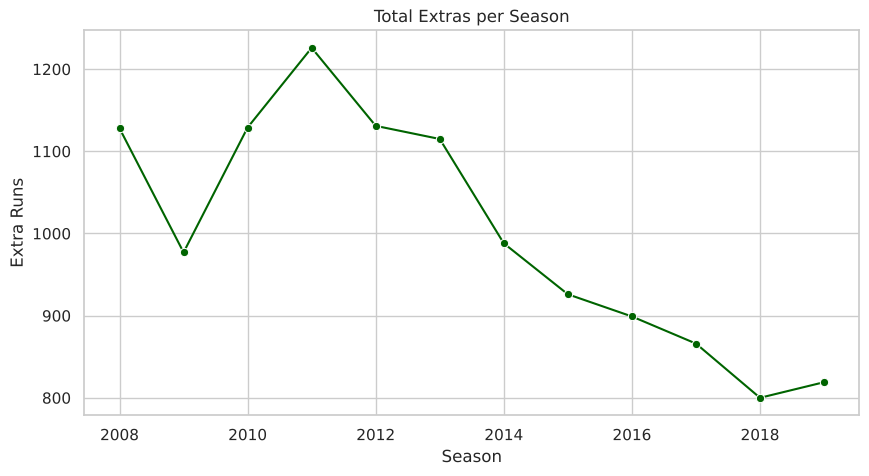

In [190]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=season_extras.index, y=season_extras.values, marker='o', color='darkgreen')
plt.title('Total Extras per Season')
plt.xlabel('Season')
plt.ylabel('Extra Runs')
plt.show()

### Question 190
Create a Seaborn `histplot` for positive `win_by_runs` values.

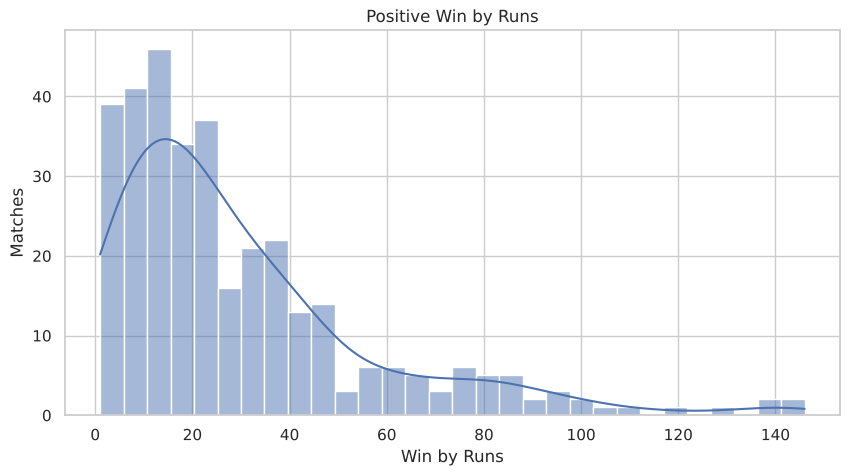

In [191]:
plt.figure(figsize=(10, 5))
sns.histplot(matches.loc[matches['win_by_runs'] > 0, 'win_by_runs'], bins=30, kde=True)
plt.title('Positive Win by Runs')
plt.xlabel('Win by Runs')
plt.ylabel('Matches')
plt.show()

### Question 191
Create a Seaborn `histplot` for positive `win_by_wickets` values.

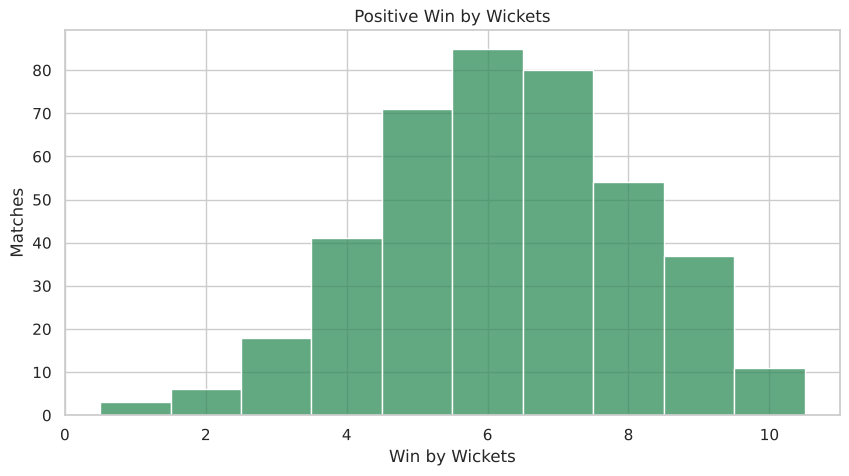

In [192]:
plt.figure(figsize=(10, 5))
sns.histplot(matches.loc[matches['win_by_wickets'] > 0, 'win_by_wickets'], discrete=True, color='seagreen')
plt.title('Positive Win by Wickets')
plt.xlabel('Win by Wickets')
plt.ylabel('Matches')
plt.show()

### Question 192
Create a Seaborn `histplot` for `batsman_runs`.

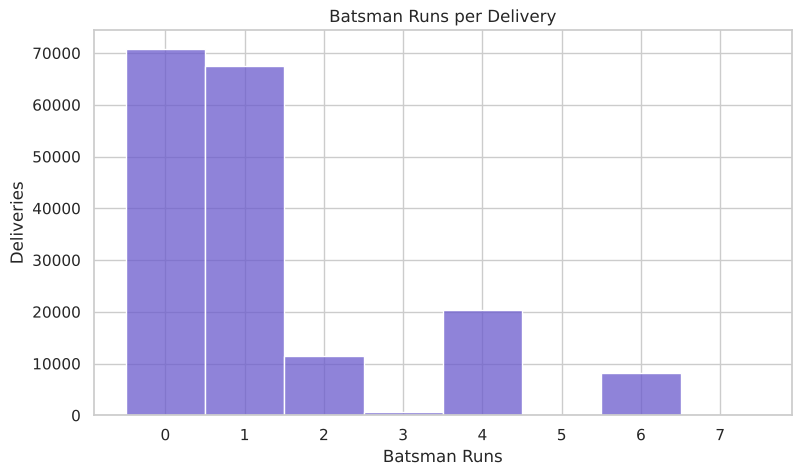

In [193]:
plt.figure(figsize=(9, 5))
sns.histplot(deliveries['batsman_runs'], discrete=True, color='slateblue')
plt.title('Batsman Runs per Delivery')
plt.xlabel('Batsman Runs')
plt.ylabel('Deliveries')
plt.show()

### Question 193
Create a Seaborn `scatterplot` for the top 20 batsmen using total runs on x-axis and sixes on y-axis.

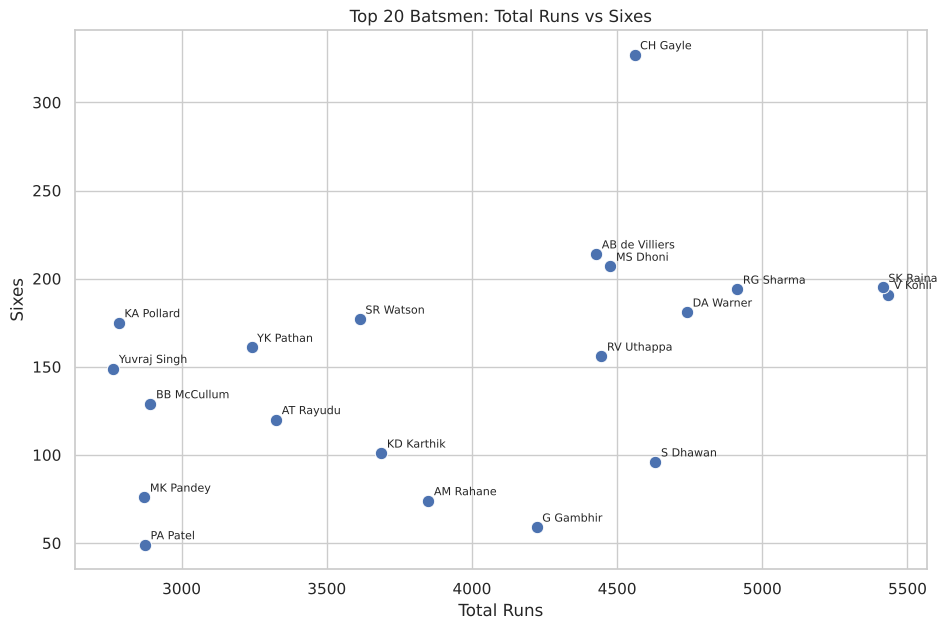

In [194]:
plt.figure(figsize=(11, 7))
sns.scatterplot(data=top20, x='runs', y='sixes', s=80)
for name, row in top20.iterrows():
    plt.annotate(name, (row['runs'], row['sixes']), fontsize=8, xytext=(4, 4), textcoords='offset points')
plt.title('Top 20 Batsmen: Total Runs vs Sixes')
plt.xlabel('Total Runs')
plt.ylabel('Sixes')
plt.show()

### Question 194
Create a Seaborn `scatterplot` for bowlers using deliveries bowled on x-axis and recorded dismissals on y-axis.

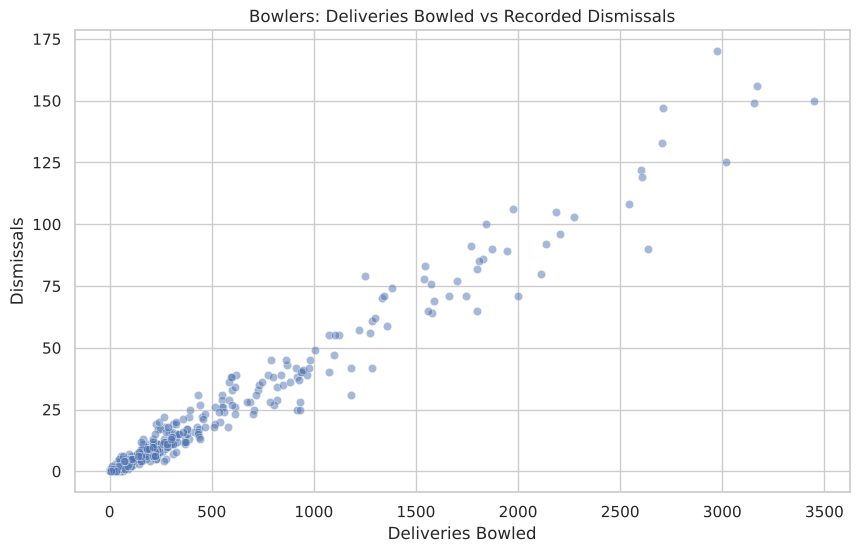

In [195]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=bowler_stats, x='deliveries', y='dismissals', alpha=0.5)
plt.title('Bowlers: Deliveries Bowled vs Recorded Dismissals')
plt.xlabel('Deliveries Bowled')
plt.ylabel('Dismissals')
plt.show()

### Question 195
Create a Seaborn `barplot` showing total runs scored by each batting team.

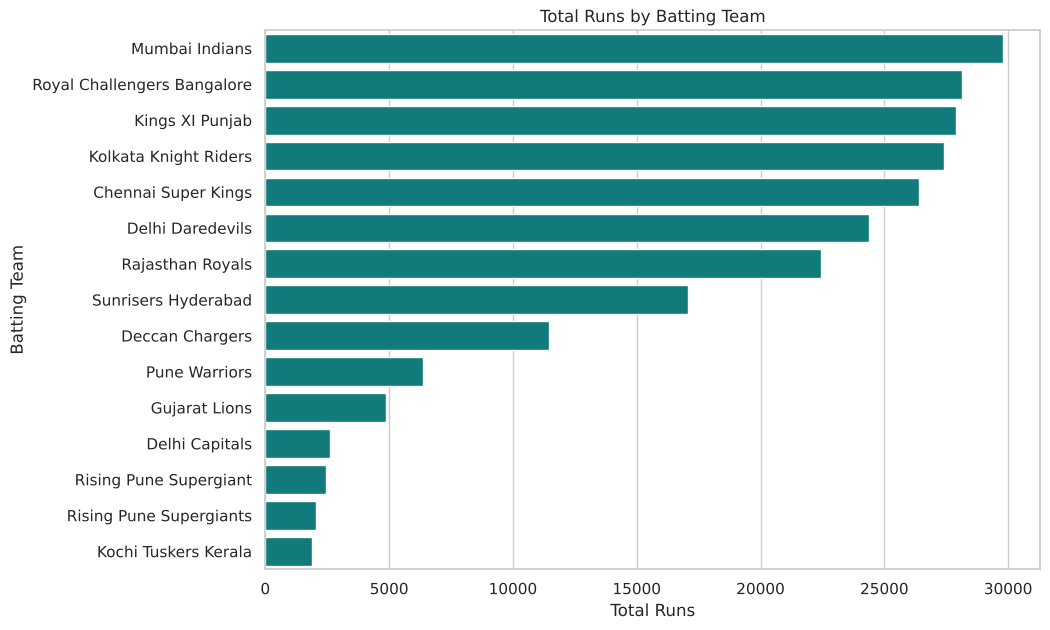

In [196]:
team_total_runs = deliveries.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(x=team_total_runs.values, y=team_total_runs.index, color='darkcyan')
plt.title('Total Runs by Batting Team')
plt.xlabel('Total Runs')
plt.ylabel('Batting Team')
plt.show()

### Question 196
Create a Seaborn `barplot` showing total extras received by each batting team.

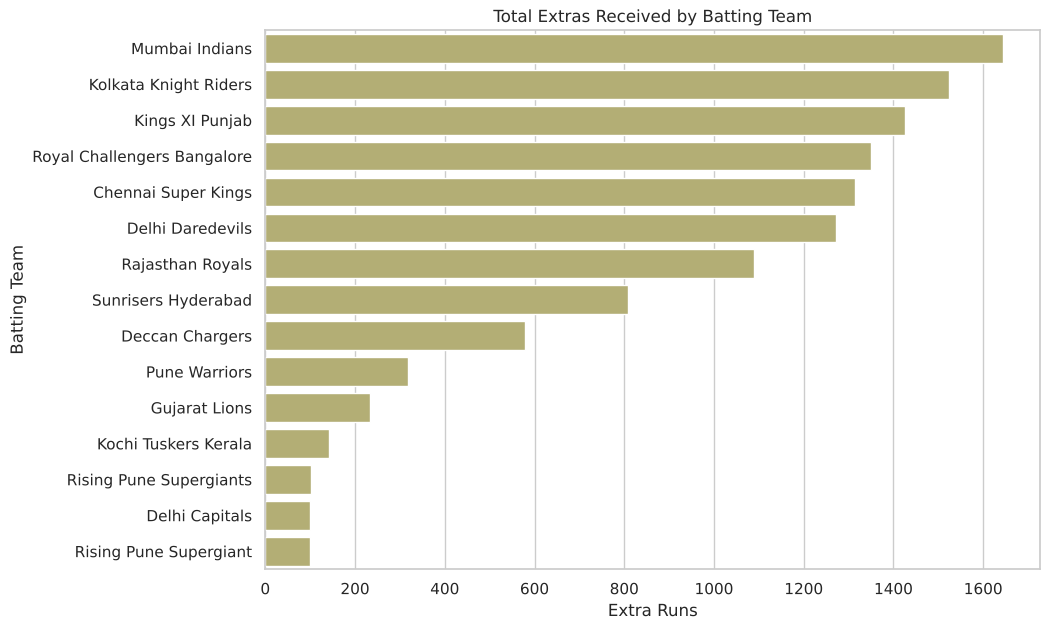

In [197]:
team_extras = deliveries.groupby('batting_team')['extra_runs'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(x=team_extras.values, y=team_extras.index, color='darkkhaki')
plt.title('Total Extras Received by Batting Team')
plt.xlabel('Extra Runs')
plt.ylabel('Batting Team')
plt.show()

### Question 197
Create a Seaborn `countplot` for the 10 most common dismissal kinds.

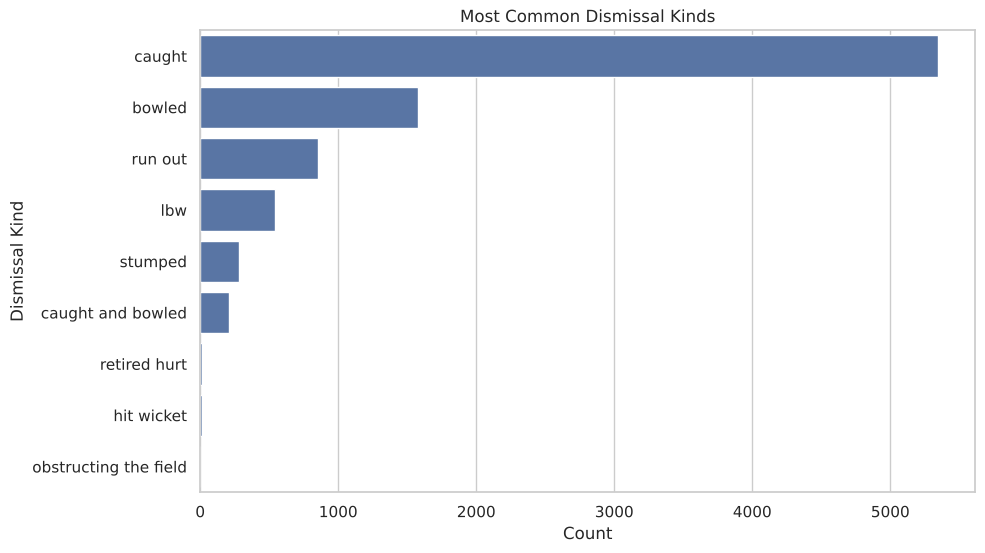

In [198]:
top_dismissals = deliveries['dismissal_kind'].value_counts().head(10).index
plt.figure(figsize=(10, 6))
sns.countplot(data=deliveries[deliveries['dismissal_kind'].isin(top_dismissals)], y='dismissal_kind', order=top_dismissals)
plt.title('Most Common Dismissal Kinds')
plt.xlabel('Count')
plt.ylabel('Dismissal Kind')
plt.show()

### Question 198
Create a correlation heatmap using numerical columns from `matches`.

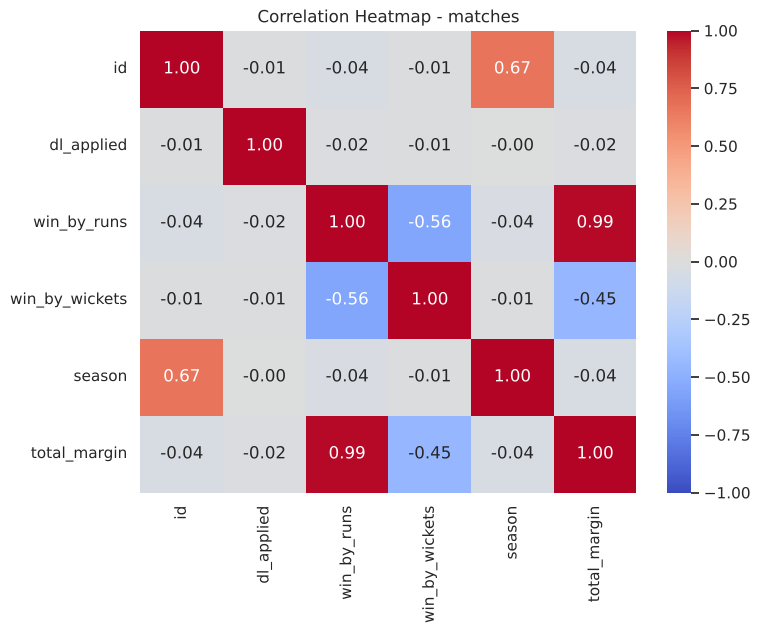

In [199]:
plt.figure(figsize=(8, 6))
sns.heatmap(matches.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap - matches')
plt.show()

### Question 199
Create a correlation heatmap using numerical columns from `deliveries`.

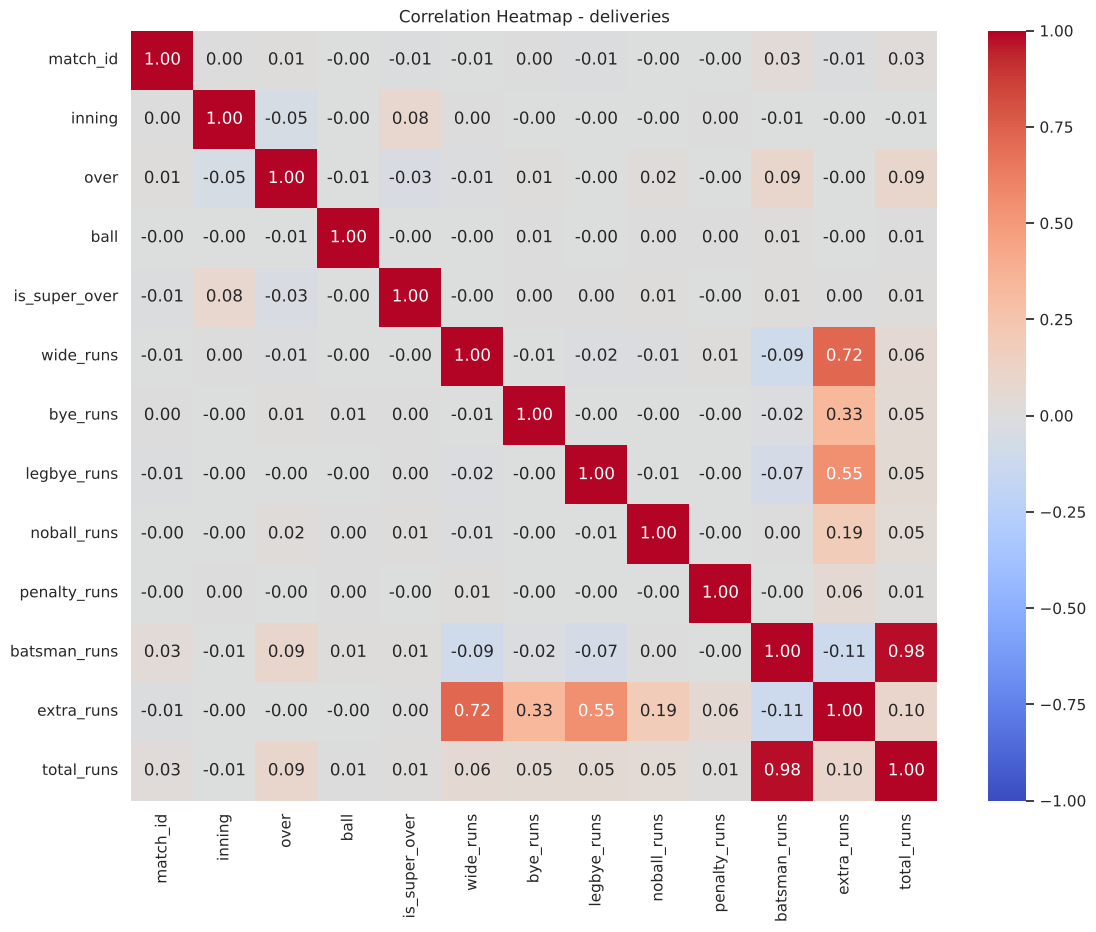

In [200]:
plt.figure(figsize=(13, 10))
sns.heatmap(deliveries.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap - deliveries')
plt.show()

### Question 200
Create one figure with two Seaborn plots side by side: top 10 run scorers and top 10 six hitters.

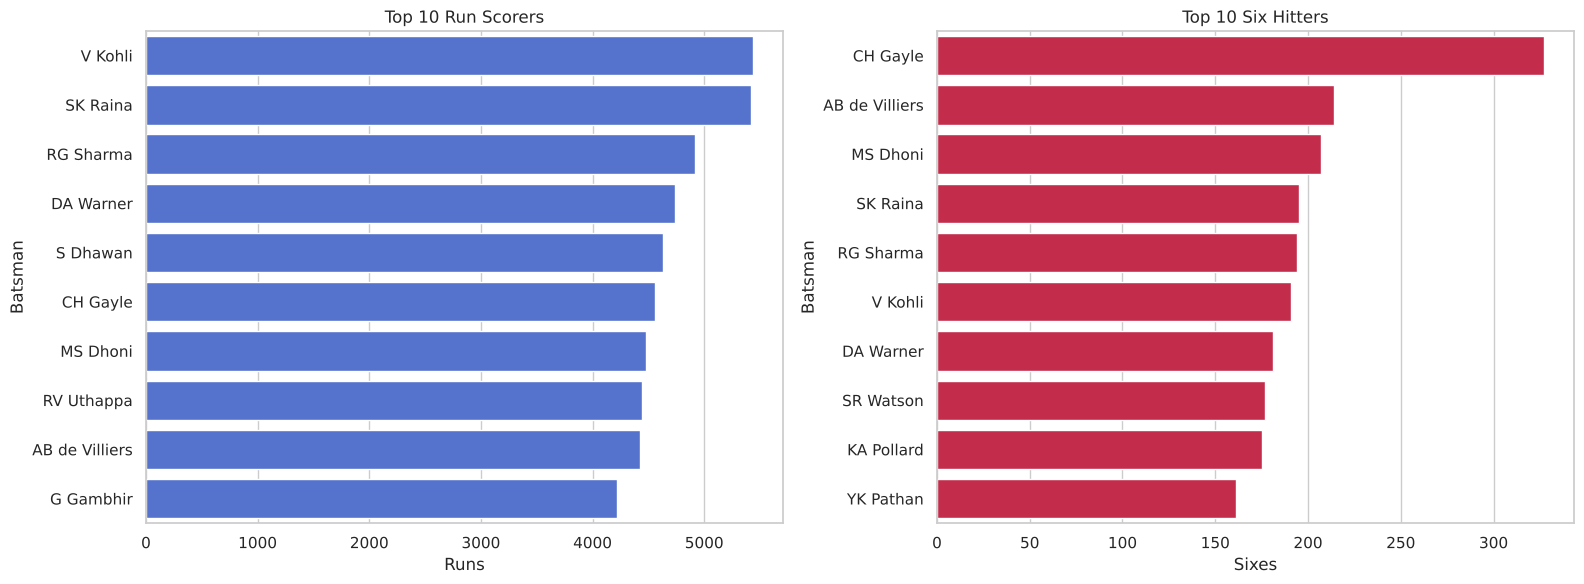

In [201]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=top10_batsmen.values, y=top10_batsmen.index, color='royalblue', ax=axes[0])
axes[0].set_title('Top 10 Run Scorers')
axes[0].set_xlabel('Runs')
axes[0].set_ylabel('Batsman')
sns.barplot(x=top_sixes.values, y=top_sixes.index, color='crimson', ax=axes[1])
axes[1].set_title('Top 10 Six Hitters')
axes[1].set_xlabel('Sixes')
axes[1].set_ylabel('Batsman')
plt.tight_layout()
plt.show()